# CSE 428 Project - Multi-task segmentation and breed classification

Oxford-IIIT Pet dataset. One network does two jobs at once: it segments the pet from the background
and predicts the breed from the same shared encoder.

**Experimental design.** Five runs, each changing exactly one variable from the one before it, so
every number in the final table is attributable to a single cause.

| # | Run | Changed from previous | Isolates |
|---|-----|----------------------|----------|
| 1 | Base U-Net | - | baseline |
| 2 | Attention U-Net | attention gates on the skips | the gating mechanism |
| 3 | Attention U-Net + augmentation | training-set augmentation | data augmentation |
| 4 | ResNet34-U-Net (random init) + aug | encoder architecture | the architecture itself |
| 5 | ResNet34-U-Net (ImageNet init) + aug | encoder weights | transfer learning |

Runs 4 and 5 differ only in the initialisation of the encoder, which is what makes the transfer
learning effect measurable rather than confounded with the architecture change.

**Order of the notebook**

1. Configuration and data preparation
2. Dataset, augmentation, stratified split, dataloaders
3. Losses, metrics and the training driver
4. Runs 1-5
5. Ablation table, threshold calibration, error analysis
6. External-image inference and artefact saving

pet iou 0.9239 and breed accuracy - 0.9243 both on test , from efficient net b0. dense net121 was higher on test but selecting on test won't be legitimate.

# 1. Configuration

Everything tunable lives in one cell, so there is no risk of two runs silently disagreeing about image size or batch size.

`QUICK_TEST` shrinks the splits and drops to two epochs. It exists so the whole notebook can be
validated in a few minutes before committing to the full run.

In [ ]:
QUICK_TEST = False          # <- set False for the real run

IMG_SIZE    = 224          # must be divisible by 32 (five downsampling stages) , standard size for imagenet models
BATCH_SIZE  = 16           #16 images per step
EPOCHS      = 30
BASE_CH     = 64           # first-level channel width of the from-scratch U-Nets, it doubles each level down
LAMBDA      = 1.0          # weight on the classification loss, total loss = L_seg + lambda * L_cls. at 1, both matters equally
LR          = 1e-3         # decoder / from-scratch learning rate
ENCODER_LR  = 1e-4         # pretrained encoder learning rate (10x lower)
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.1         #softens the classification target so when the model doesn't predict wrong when its 95% confident
SEED        = 42
NUM_WORKERS = 2
USE_AMP     = True         # mixed precision, roughly 2x faster on a T4

# bonus task 1 - well-established classifier architectures to compare as U-Net encoders.
BACKBONES   = ["mobilenet_v3_large", "efficientnet_b0", "densenet121"]
CKPT_DIR    = "/kaggle/working"

In [ ]:
import os, glob, json, random, time, math, warnings
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms.functional as TF
from torchvision import transforms
from torchvision.models import resnet34, ResNet34_Weights
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", category=UserWarning)
#4 separate random number generator. Aug uses Python's random, weight initialization uses pytorch's.
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = USE_AMP and device == "cuda" #automatic mixed precision - using 16-bit float instead of 32 for faster result and less memory usage. (gpu feature)

# torch moved GradScaler/autocast into torch.amp; fall back for older builds
try:
    from torch.amp import autocast as _autocast, GradScaler as _GradScaler  #gradscaler scales the loss up so small 16 bit gradients don't vanish to zero
    _GradScaler("cuda", enabled=False)
    def make_scaler(en): return _GradScaler("cuda", enabled=en)
    def amp_ctx(en):     return _autocast("cuda", enabled=en)
except (ImportError, TypeError):
    from torch.cuda.amp import autocast as _autocast, GradScaler as _GradScaler
    def make_scaler(en): return _GradScaler(enabled=en)
    def amp_ctx(en):     return _autocast(enabled=en)

os.makedirs(CKPT_DIR, exist_ok=True)
print(f"Device      - {device}")
print(f"Mixed prec. - {USE_AMP}")
print(f"Quick test  - {QUICK_TEST}")

Device      - cuda
Mixed prec. - True
Quick test  - False


# 2. Data preparation

## Download

Plain `subprocess` rather than `!wget` magics so the cell is a normal conditional and re-running it
after the data is already present is free. The archives are removed after extraction because Kaggle
counts them against the 20 GB working-directory limit.

In [ ]:
import subprocess, tarfile

BASE = "https://www.robots.ox.ac.uk/~vgg/data/pets/data"

def fetch(name):
    if not os.path.exists(name):
        r = subprocess.run(["wget", "-q", f"{BASE}/{name}"])
        assert r.returncode == 0 and os.path.exists(name), \
            f"download of {name} failed - is Internet switched on in the Settings sidebar?"
    with tarfile.open(name) as t:
        try:
            # filter="data" refuses absolute paths, ../ escapes and symlinks.
            # The argument does not exist before Python 3.12.
            t.extractall("/kaggle/working", filter="data")
        except TypeError:
            t.extractall("/kaggle/working")
    os.remove(name)

if not (os.path.isdir("/kaggle/working/images") and
        os.path.isdir("/kaggle/working/annotations")):
    for f in ("images.tar.gz", "annotations.tar.gz"):
        fetch(f)
    print("Downloaded and extracted.")
else:
    print("Already present, skipping download.")

Downloaded and extracted.


## Locating and pairing the files

Images live in `images/` and masks in `annotations/trimaps/`. Both the working and the input
directories are searched, so the notebook still finds the data if the dataset is attached as a
Kaggle input rather than downloaded.

Filenames follow `<breed>_<number>.jpg` and the mask shares the stem with a `.png` extension.
The breed comes from stripping the trailing number. The dataset capitalises cat breeds and leaves
dog breeds lowercase, so species falls out of the first character.

In [ ]:
ROOTS = ["/kaggle/working", "/kaggle/input"]
image_paths, trimap_paths = [], []
for root in ROOTS:
    image_paths  += glob.glob(os.path.join(root, "**", "images",  "*.jpg"), recursive=True)
    trimap_paths += glob.glob(os.path.join(root, "**", "trimaps", "*.png"), recursive=True)
image_paths = sorted(image_paths)                                                              #sorting makes the sample list deterministic
trimap_dir  = os.path.dirname(sorted(trimap_paths)[0])

samples, skipped = [], 0
for img_path in image_paths:
    stem = os.path.basename(img_path)[:-4]
    if stem.startswith("."):                      # macOS resource-fork files in the archive
        continue
    trimap_path = os.path.join(trimap_dir, stem + ".png")
    if not os.path.exists(trimap_path):  #a few images have no mask. counted and skipped, the count is printed.
        skipped += 1
        continue
    breed = stem.rsplit("_", 1)[0]      # rsplit splits from the right and 1 means at most once. Abyssinian_101 -> Abyssinian
    samples.append({"image": img_path, "trimap": trimap_path, "breed": breed,
                    "species": "cat" if breed[0].isupper() else "dog"})  #capitalizes cat breed, so the first letter knows if its cat or dog.
#uppercase sorts before lowercase; 12 cat breeds = 0-11, 25 dogs are 12-36

breeds       = sorted({s["breed"] for s in samples})
breed_to_idx = {b: i for i, b in enumerate(breeds)}
idx_to_breed = {i: b for b, i in breed_to_idx.items()}
NUM_CLASSES  = len(breeds)
IS_CAT       = torch.tensor([b[0].isupper() for b in breeds], device=device)

n_cats = sum(s["species"] == "cat" for s in samples)
print(f"Usable image / mask pairs - {len(samples)}  (skipped {skipped} unmatched)")
print(f"Cats - {n_cats} | Dogs - {len(samples) - n_cats}")
print(f"Breeds - {NUM_CLASSES}")

counts = pd.Series([s["breed"] for s in samples]).value_counts()
print(f"Images per breed - min {counts.min()}, max {counts.max()}, median {int(counts.median())}")

Usable image / mask pairs - 7390  (skipped 0 unmatched)
Cats - 2400 | Dogs - 4990
Breeds - 37
Images per breed - min 191, max 200, median 200


## Trimap to binary mask

Trimaps label 1 for pet, 2 for background and 3 for boundary. The task folds the boundary into the
foreground, so 1 and 3 both map to 1 and the problem becomes binary.

In [ ]:
def load_binary_mask(trimap_path):
    trimap = np.array(Image.open(trimap_path))
    return np.where((trimap == 1) | (trimap == 3), 1, 0).astype(np.uint8)  #pet and boundary = foregroud = 1, background = 0

raw = np.array(Image.open(samples[0]["trimap"]))
print("Trimap values      -", np.unique(raw))
print("Binary mask values -", np.unique(load_binary_mask(samples[0]["trimap"])))
print(f"Mean foreground fraction (50 images) - "
      f"{np.mean([load_binary_mask(s['trimap']).mean() for s in samples[:50]]):.3f}")

Trimap values      - [1 2 3]
Binary mask values - [0 1]
Mean foreground fraction (50 images) - 0.372


The last line matters for reading the results later. The pet covers only about a third of the frame,
so background is the majority class and background IoU is the easier of the two. Any metric averaged
over both classes is therefore optimistic, which is why this notebook reports the pet-class IoU
separately everywhere.

## Mask visualisation

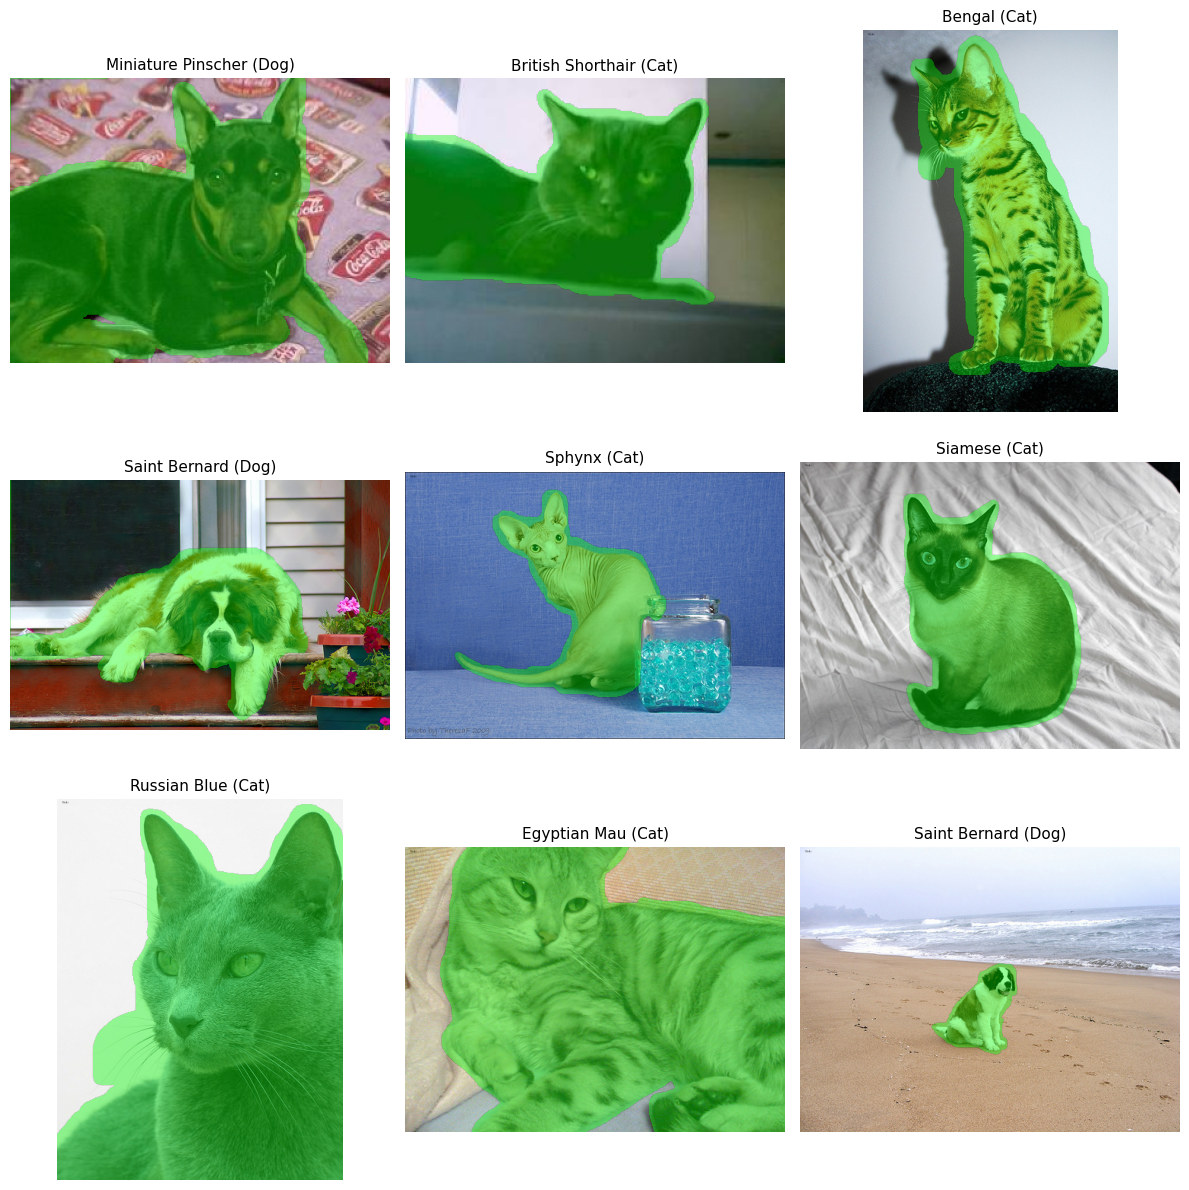

In [ ]:
def show_overlay_grid(samples, n=9, seed=SEED):
    rng = random.Random(seed)                      # local RNG, does not disturb global state, creates a private random generator.
    picks = rng.sample(range(len(samples)), n)
    rows = cols = int(n ** 0.5)
    fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
    for ax, idx in zip(axes.ravel(), picks):
        s = samples[idx]
        image = np.array(Image.open(s["image"]).convert("RGB"))   # guards grayscale / RGBA files
        mask = load_binary_mask(s["trimap"])
        overlay = np.zeros((*mask.shape, 4)); overlay[mask == 1] = [0, 1, 0, 0.4]  #RGBA = starts with all 0, then at every pixel where the mask is 1, green = 1, alpha = 0.4
        ax.imshow(image); ax.imshow(overlay)   #2 calls because one draw the photo, another overlay on top
        ax.set_title(f"{s['breed'].replace('_',' ').title()} ({s['species'].title()})", fontsize=11)
        ax.axis("off")
    plt.tight_layout(); plt.show()

show_overlay_grid(samples, 9)

# 3. Dataset, augmentation and dataloaders

Each item returns the image tensor, the binary mask and the breed index.

**Mask resizing uses `Image.NEAREST`.** Bilinear averages neighbouring pixels and would produce
fractional values like 0.4 in what has to be a 0/1 mask. Nearest neighbour copies the closest pixel
and keeps it binary.

**Normalisation is ImageNet mean/std.** This is required for run 5, where the encoder was trained on
ImageNet-normalised inputs, and it is applied to every run so the five models see identical data.

**Augmentation pairs the geometry.** Flip, rotation and resized crop are applied to the image and the
mask with the same parameters so they stay aligned; colour jitter touches the image only, since
shifting the brightness of a mask is meaningless. The flag is off by default and is only ever set on
the training copy of the dataset.

In [ ]:
#using imagenet's stats because run5-8 are imagenet pretrained encoders
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
jitter = transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)

class PetDataset(Dataset):
    def __init__(self, samples, breed_to_idx, train=False):
        self.samples, self.breed_to_idx, self.train = samples, breed_to_idx, train

    def __len__(self):   #how many items
        return len(self.samples)

    def __getitem__(self, idx):  #returns item number idx.
        s = self.samples[idx]
        image = Image.open(s["image"]).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        mask  = Image.fromarray(load_binary_mask(s["trimap"])).resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)

        #geometry applies to both; color jitter only applies to image
        if self.train:
            if random.random() < 0.5:
                image, mask = TF.hflip(image), TF.hflip(mask)
            angle = random.uniform(-15, 15)
            image = TF.rotate(image, angle, interpolation=TF.InterpolationMode.BILINEAR)
            mask  = TF.rotate(mask,  angle, interpolation=TF.InterpolationMode.NEAREST)
            i, j, h, w = transforms.RandomResizedCrop.get_params(image, scale=(0.8, 1.0), ratio=(0.9, 1.1))
            image = TF.resized_crop(image, i, j, h, w, [IMG_SIZE, IMG_SIZE], TF.InterpolationMode.BILINEAR)
            mask  = TF.resized_crop(mask,  i, j, h, w, [IMG_SIZE, IMG_SIZE], TF.InterpolationMode.NEAREST)
            image = jitter(image)

        image = TF.normalize(TF.to_tensor(image), IMAGENET_MEAN, IMAGENET_STD)   #to_tensor - 1. reorders (H,W,C)->(C,H,W)   2. scales 0-255 integers to 0.0-1.0 floats
        mask  = torch.from_numpy(np.array(mask)).float().unsqueeze(0)            #unsqueeze adds a channel dimension, so 224,224 -> 1,224,224 (model -> N,1,H,W)
        return image, mask, self.breed_to_idx[s["breed"]]


def denorm(t):
    # undo ImageNet normalisation so a tensor can be displayed
    m = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    s = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t.detach().cpu() * s + m).clamp(0, 1).permute(1, 2, 0).numpy()

plain_ds = PetDataset(samples, breed_to_idx, train=False)  #validation and test
aug_ds   = PetDataset(samples, breed_to_idx, train=True)   #train

_i, _m, _l = plain_ds[0]
print(f"Image {tuple(_i.shape)} | Mask {tuple(_m.shape)} | Label {_l} ({idx_to_breed[_l]})")
print(f"Mask values after NEAREST resize - {torch.unique(_m).tolist()}")

Image (3, 224, 224) | Mask (1, 224, 224) | Label 0 (Abyssinian)
Mask values after NEAREST resize - [0.0, 1.0]


## Sanity check: the mask follows the image through augmentation

Misaligned augmentation is silent - the model still trains, the loss still falls, and the
segmentation is quietly supervised against the wrong pixels. This check makes the failure loud.

An image is drawn whose foreground is exactly its own mask. It is pushed through the augmentation
pipeline thirty times with the colour jitter disabled, and each time the shape recovered from the
image is compared with the augmented mask. Only boundary pixels should ever disagree, because the
image is resampled bilinearly and the mask nearest-neighbour.

In [ ]:
#it builds an image whose foreground is its own mask. It augments it 30 times with different seeds and checks whether the shape in image still matches the mask.
def check_alignment(trials=30, tol=0.02):
    global jitter
    tmp = "/kaggle/working/_align"
    os.makedirs(tmp, exist_ok=True)
    shape = np.zeros((200, 200), np.uint8); shape[40:160, 60:140] = 1
    Image.fromarray(shape * 255).convert("RGB").save(f"{tmp}/Probe_1.jpg", quality=100)
    Image.fromarray(np.where(shape == 1, 1, 2).astype(np.uint8)).save(f"{tmp}/Probe_1.png")
    probe = [{"image": f"{tmp}/Probe_1.jpg", "trimap": f"{tmp}/Probe_1.png", "breed": "Probe"}]

    saved, jitter = jitter, (lambda im: im)          # isolate geometry from colour
    worst = 0.0
    try:
        for t in range(trials):
            random.seed(t); torch.manual_seed(t)
            gi, gm, _ = PetDataset(probe, {"Probe": 0}, train=True)[0]
            img_fg = (denorm(gi)[:, :, 0] > 0.5).astype(np.uint8)
            worst = max(worst, float((img_fg != gm.squeeze(0).numpy().astype(np.uint8)).mean()))
    finally:
        jitter = saved
        random.seed(SEED); torch.manual_seed(SEED)

    status = "PASS" if worst < tol else "FAIL"
    print(f"[{status}] worst image/mask disagreement over {trials} augmentations: {worst*100:.2f}% "
          f"of pixels (tolerance {tol*100:.0f}%, boundary resampling only)")
    assert worst < tol, "image and mask are not being augmented with the same parameters"

check_alignment()

[PASS] worst image/mask disagreement over 30 augmentations: 0.37% of pixels (tolerance 2%, boundary resampling only)


## Stratified split and dataloaders

A 70/15/15 split, **stratified by breed**. With 37 classes averaging under 200 images each, an
unstratified random split leaves some breeds with noticeably different representation in train and
test, which adds variance to a breed-accuracy number that is already the weakest metric here.
Stratifying removes that as a source of noise.

The split is computed once as index arrays and then wrapped around two copies of the dataset - an
augmenting copy for training and a plain copy for everything else. Augmenting the validation or test
set would make the reported numbers meaningless, so the flag is only ever set on the training copy.
Both `train_loader` and `aug_train_loader` cover exactly the same images.

In [ ]:
y   = np.array([breed_to_idx[s["breed"]] for s in samples])
idx = np.arange(len(samples))

tr_idx, tmp_idx = train_test_split(idx, test_size=0.30, stratify=y, random_state=SEED)
val_idx, test_idx = train_test_split(tmp_idx, test_size=0.50, stratify=y[tmp_idx], random_state=SEED)

if QUICK_TEST:
    EPOCHS = 2
    tr_idx, val_idx, test_idx = tr_idx[:256], val_idx[:128], test_idx[:128]
    print(">> QUICK_TEST: subsampled splits and EPOCHS=2. Results are meaningless, wiring is not.\n")

assert not (set(tr_idx) & set(val_idx)) and not (set(tr_idx) & set(test_idx)) \
       and not (set(val_idx) & set(test_idx)), "splits overlap - test set is contaminated"

def loader(ds, ids, shuffle):
    return DataLoader(Subset(ds, list(ids)), batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=(device == "cuda"),
                      persistent_workers=NUM_WORKERS > 0, drop_last=False)

train_loader     = loader(plain_ds, tr_idx,   True)   #plain images -> shuffled: shuffling stops the model learning the order of data
aug_train_loader = loader(aug_ds,   tr_idx,   True)   #same images -> augmented + shuffled
val_loader       = loader(plain_ds, val_idx,  False)
test_loader      = loader(plain_ds, test_idx, False)  #plain images -> not shuffled

images, masks, labels = next(iter(train_loader))
print(f"Train {len(tr_idx)} | Val {len(val_idx)} | Test {len(test_idx)}")
print(f"Batch - images {tuple(images.shape)} | masks {tuple(masks.shape)} | labels {tuple(labels.shape)}")
print(f"Mask dtype {masks.dtype}, values {torch.unique(masks).tolist()}")
print(f"Label range [{labels.min().item()}, {labels.max().item()}] within [0, {NUM_CLASSES-1}]")
if not QUICK_TEST:
    print(f"Breeds present - train {len(set(y[tr_idx]))}, val {len(set(y[val_idx]))}, "
          f"test {len(set(y[test_idx]))} of {NUM_CLASSES}")

Train 5173 | Val 1108 | Test 1109
Batch - images (16, 3, 224, 224) | masks (16, 1, 224, 224) | labels (16,)
Mask dtype torch.float32, values [0.0, 1.0]
Label range [4, 31] within [0, 36]
Breeds present - train 37, val 37, test 37 of 37


# 4. Losses, metrics and the training driver

## Loss functions

**Segmentation: `BCEWithLogitsLoss` + soft Dice.** BCE takes raw logits and applies the sigmoid
internally in a numerically safer way, but it is a per-pixel loss and the background outnumbers the
foreground roughly two to one, so it is happy with a model that shaves the pet outline. Dice is
computed over the whole predicted region and penalises exactly that. The sum is the standard pairing
for binary segmentation.

Dice is computed on `logits.float()`. Under mixed precision the logits arrive as fp16, and summing
over a 224x224 map would overflow the fp16 maximum of 65504 and produce `inf`. The cast is not
cosmetic.

**Classification: cross entropy with label smoothing 0.1.** Several of the 37 breeds are genuinely
hard to tell apart at this resolution. Smoothing stops the network from driving a single logit to
saturation on those, which is where a confident wrong answer comes from.

`LAMBDA` weights the classification term against the segmentation term and is left at 1.0.

In [ ]:
bce_criterion = nn.BCEWithLogitsLoss()
cls_criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)

def dice_loss(logits, targets, eps=1.0):
    # float() cast is required: under AMP a 224x224 fp16 sum overflows to inf
    p = torch.sigmoid(logits.float())
    t = targets.float()
    num = 2 * (p * t).sum(dim=(1, 2, 3)) + eps   #eps = 1, prevents 0/0
    den = p.sum(dim=(1, 2, 3)) + t.sum(dim=(1, 2, 3)) + eps
    return 1 - (num / den).mean()

def seg_loss_fn(logits, targets):
    return bce_criterion(logits.float(), targets) + dice_loss(logits, targets)

# quick numeric check: a confident-correct prediction should cost ~0, a confident-wrong one ~1
_t = torch.ones(2, 1, 8, 8)
print(f"dice_loss  perfect {dice_loss(torch.full((2,1,8,8), 20.0), _t):.5f} | "
      f"worst {dice_loss(torch.full((2,1,8,8), -20.0), _t):.5f}")

dice_loss  perfect 0.00000 | worst 0.98462


## Metrics

`run_epoch` does one pass over a loader and returns the losses and the metrics from that same pass,
so no second sweep is needed. Prediction tensors are detached before thresholding and argmax,
otherwise those operations would extend the autograd graph for nothing, and the running loss totals
use `.item()` so they hold floats rather than keeping graphs alive.

What is reported and why:

- **Pet IoU** - intersection over union on the foreground class alone. This is what most people mean
  by "the IoU" on this task and it is the honest number.
- **mIoU** - the mean over background and foreground. Reported because it is the conventional
  multi-class metric, but background is the easy majority class so this always reads higher than
  Pet IoU. Both are shown side by side so the difference is visible rather than hidden.
- **Pet Dice / mDice** - the same distinction for Dice.
- **Cls Acc, Top-5 Acc** - top-1 and top-5 breed accuracy. With 37 fine-grained classes, top-5
  says whether the model is close or lost.
- **Species Acc** - cat versus dog, derived from the *predicted breed*. If species accuracy is high
  while breed accuracy is low, the encoder has learned coarse structure but not fine texture.
- **Precision / Recall / F1** - macro averages over the 37 breeds, from a running confusion matrix.
  Macro rather than micro because the breeds are not perfectly balanced.

The confusion matrix is accumulated with `np.bincount` rather than a Python loop over the batch, and
it is *returned* rather than reduced to scalars and thrown away, so the per-class analysis later
costs nothing extra.

In [ ]:
METRIC_COLS = ["Pixel Acc", "Pet IoU", "mIoU", "Pet Dice", "mDice",
               "Cls Acc", "Top-5 Acc", "Species Acc", "Precision", "Recall", "F1"]

def run_epoch(model, loader, train, optimizer=None, scaler=None):
    model.train() if train else model.eval()

    tot = seg_l = cls_l = 0.0
    n = 0
    inter, union   = np.zeros(2), np.zeros(2)
    pred_px, true_px = np.zeros(2), np.zeros(2)
    correct_px = total_px = top5 = sp_correct = 0
    cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for images, masks, labels in loader:
            images = images.to(device, non_blocking=True)
            masks  = masks.to(device, non_blocking=True).float()
            labels = labels.to(device, non_blocking=True).long()

            with amp_ctx(USE_AMP):
                seg_logits, cls_logits = model(images)
                L_seg = seg_loss_fn(seg_logits, masks)
                L_cls = cls_criterion(cls_logits.float(), labels)
                loss  = L_seg + LAMBDA * L_cls

            if train:
                optimizer.zero_grad(set_to_none=True)
                if scaler is not None and scaler.is_enabled():
                    scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
                else:
                    loss.backward(); optimizer.step()

            bs = images.size(0); n += bs
            tot   += loss.item()  * bs
            seg_l += L_seg.item() * bs
            cls_l += L_cls.item() * bs

            seg_pred = (torch.sigmoid(seg_logits.detach().float()) > 0.5).long().squeeze(1)
            seg_true = masks.long().squeeze(1)
            correct_px += (seg_pred == seg_true).sum().item()
            total_px   += seg_true.numel()
            for c in (0, 1):
                p, t = (seg_pred == c), (seg_true == c)
                inter[c]   += (p & t).sum().item()
                union[c]   += (p | t).sum().item()
                pred_px[c] += p.sum().item()
                true_px[c] += t.sum().item()

            cl  = cls_logits.detach().float()
            k   = min(5, cl.size(1))
            top5 += (cl.topk(k, 1).indices == labels.unsqueeze(1)).any(1).sum().item()
            cls_pred = cl.argmax(1)
            sp_correct += (IS_CAT[cls_pred] == IS_CAT[labels]).sum().item()
            a, b = labels.cpu().numpy(), cls_pred.cpu().numpy()
            cm += np.bincount(a * NUM_CLASSES + b,
                              minlength=NUM_CLASSES ** 2).reshape(NUM_CLASSES, NUM_CLASSES)

    iou  = inter / np.maximum(union, 1e-9)
    dice = 2 * inter / np.maximum(pred_px + true_px, 1e-9)
    tp   = np.diag(cm).astype(np.float64)
    fp, fn = cm.sum(0) - tp, cm.sum(1) - tp
    prec = tp / np.maximum(tp + fp, 1e-9)
    rec  = tp / np.maximum(tp + fn, 1e-9)
    f1   = 2 * prec * rec / np.maximum(prec + rec, 1e-9)
    seen = cm.sum(1) > 0                              # ignore breeds absent from this split

    return {"loss": tot / n, "seg_loss": seg_l / n, "cls_loss": cls_l / n,
            "Pixel Acc": correct_px / total_px,
            "Pet IoU": iou[1], "Bg IoU": iou[0], "mIoU": iou.mean(),
            "Pet Dice": dice[1], "mDice": dice.mean(),
            "Cls Acc": tp.sum() / cm.sum(), "Top-5 Acc": top5 / n, "Species Acc": sp_correct / n,
            "Precision": prec[seen].mean(), "Recall": rec[seen].mean(), "F1": f1[seen].mean()}, cm

## Training driver

One function trains every model, so all five runs go through identical code and the comparison
between them is fair. Loaders are arguments rather than globals, which is what lets the augmented
runs swap in a different training loader without touching anything else.

Four things differ from a naive loop, each for a reason:

**AdamW with weight decay** rather than plain Adam. Adam's `weight_decay` is L2 added to the
gradient, which interacts badly with the adaptive step size; AdamW applies it as true decoupled
decay. With 31M parameters on 5,000 images, some regularisation is not optional.

**Cosine annealing.** A constant learning rate leaves the model bouncing around a minimum it cannot
settle into - visible as a validation loss that oscillates instead of converging. Cosine decay to
near zero over the run fixes that and costs nothing.

**Discriminative learning rates.** When a model exposes `encoder_parameters()`, the pretrained
encoder is given a rate ten times lower than the freshly initialised decoder and head. A pretrained
encoder already holds good features; hitting it with the same rate as random weights destroys them
in the first few hundred steps. An assertion checks the two parameter groups partition the model
exactly, because a parameter silently left out of the optimiser never trains and nothing warns you.

**Two checkpoints.** The best total validation loss and the best validation breed accuracy are
usually not the same epoch, because the total loss covers both tasks. Saving only on total loss
throws away the best classifier the run produced. Both are kept; the tables state which is used.

Mixed precision is on by default. `GradScaler` multiplies the loss before the backward pass so fp16
gradients do not underflow to zero, then unscales before the optimiser step.

In [ ]:
def train_model(model, name, train_loader, val_loader, epochs=None, lr=LR,
                encoder_lr=None, verbose=True):
    epochs = epochs or EPOCHS
    ck_loss = f"{CKPT_DIR}/{name}_bestloss.pth"
    ck_cls  = f"{CKPT_DIR}/{name}_bestcls.pth"

    if encoder_lr is not None and hasattr(model, "encoder_parameters"):
        enc = list(model.encoder_parameters()); dec = list(model.decoder_parameters())
        ids_e, ids_d = {id(p) for p in enc}, {id(p) for p in dec}
        assert ids_e.isdisjoint(ids_d), "parameter groups overlap"
        assert ids_e | ids_d == {id(p) for p in model.parameters()}, \
            "parameter groups do not cover the model - something would never train"
        optimizer = torch.optim.AdamW([{"params": enc, "lr": encoder_lr},
                                       {"params": dec, "lr": lr}], weight_decay=WEIGHT_DECAY)
        head = f"encoder lr {encoder_lr:g}, decoder lr {lr:g}"
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
        head = f"lr {lr:g}"

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = make_scaler(USE_AMP)

    n_par = sum(p.numel() for p in model.parameters())
    if verbose:
        print(f"{name} | {n_par:,} params | {head} | AdamW wd {WEIGHT_DECAY:g} | cosine | {epochs} epochs")

    hist, best_loss, best_cls, t_start = [], float("inf"), -1.0, time.time()
    for ep in range(1, epochs + 1):
        t0 = time.time()
        tr, _ = run_epoch(model, train_loader, True, optimizer, scaler)
        vl, _ = run_epoch(model, val_loader, False)
        scheduler.step()
        dt = time.time() - t0

        hist.append({"epoch": ep, "lr": optimizer.param_groups[-1]["lr"], "sec": dt,
                     **{f"train_{k}": v for k, v in tr.items()},
                     **{f"val_{k}": v for k, v in vl.items()}})

        tags = []
        if vl["loss"] < best_loss:
            best_loss = vl["loss"]; torch.save(model.state_dict(), ck_loss); tags.append("loss")
        if vl["Cls Acc"] > best_cls:
            best_cls = vl["Cls Acc"]; torch.save(model.state_dict(), ck_cls); tags.append("cls")

        if verbose:
            print(f"ep {ep:>3}/{epochs} | {dt:5.1f}s | train {tr['loss']:.4f} | val {vl['loss']:.4f} "
                  f"| PetIoU {vl['Pet IoU']:.4f} | ClsAcc {vl['Cls Acc']:.4f} "
                  f"| Top5 {vl['Top-5 Acc']:.4f}"
                  + (f"  <- saved [{', '.join(tags)}]" if tags else ""))

    df = pd.DataFrame(hist)
    df.to_csv(f"{CKPT_DIR}/{name}_history.csv", index=False)
    if verbose:
        print(f"done in {(time.time()-t_start)/60:.1f} min | "
              f"best val loss {best_loss:.4f} | best val ClsAcc {best_cls:.4f}")
    return df


def evaluate(model, ckpt=None, splits=("Train", "Val", "Test")):
    if ckpt:
        model.load_state_dict(torch.load(ckpt, map_location=device))
    lut = {"Train": train_loader, "Val": val_loader, "Test": test_loader}
    rows, cms = {}, {}
    for k in splits:
        m, cm = run_epoch(model, lut[k], False)
        rows[k], cms[k] = m, cm
    return pd.DataFrame(rows).T[METRIC_COLS].round(4), cms

`evaluate` always uses the plain, unaugmented loaders - including for the Train row. The training row
therefore measures what the model actually learned, not how it performs on distorted copies of the
training set, which is what makes the train-versus-validation gap a meaningful overfitting signal.

## Automatic observations

Rather than leaving prose to be written by hand after the run, the interpretation is generated from
the numbers. Two benefits: the commentary can never disagree with the table above it, and the
over/underfitting call is made by a stated rule instead of by eye.

The rule: a model is **overfitting** when the train-minus-validation breed-accuracy gap exceeds 0.15;
**underfitting** when train accuracy is itself below 0.55 with a gap under 0.10 (it cannot even fit
the data it has seen); otherwise **balanced**. These are thresholds, not laws, and the raw numbers
are printed alongside the verdict so the reader can disagree.

In [ ]:
def diagnose(res):
    tr, vl = res.loc["Train", "Cls Acc"], res.loc["Val", "Cls Acc"]
    gap = tr - vl
    if gap > 0.15:
        v = "overfitting - it fits the training set far better than the validation set"
    elif tr < 0.55 and gap < 0.10:
        v = "underfitting - it has not even fitted the training set, so capacity or training length is the binding constraint, not data"
    else:
        v = "reasonably balanced"
    return v, tr, vl, gap


def observe(name, res, hist=None):
    v, tr, vl, gap = diagnose(res)
    t = res.loc["Test"]
    print(f"--- {name} ---")
    print(f"Segmentation : Pet IoU {t['Pet IoU']:.4f}, mIoU {t['mIoU']:.4f}, Pet Dice {t['Pet Dice']:.4f}")
    print(f"               mIoU reads {t['mIoU']-t['Pet IoU']:+.4f} above Pet IoU because it averages in "
          f"the easy background class.")
    print(f"Breed        : top-1 {t['Cls Acc']:.4f}, top-5 {t['Top-5 Acc']:.4f}, macro F1 {t['F1']:.4f}")
    print(f"               species (cat vs dog) from the predicted breed: {t['Species Acc']:.4f}")
    if t['Species Acc'] > 0.75 and t['Species Acc'] - t['Cls Acc'] > 0.25:
        print(f"               coarse structure is learned ({t['Species Acc']:.2f} species) well before "
              f"fine texture ({t['Cls Acc']:.2f} breed).")
    elif t['Species Acc'] < 0.65:
        print(f"               species accuracy is near chance - the classifier is not yet separating "
              f"even cats from dogs reliably.")
    print(f"Fit          : train {tr:.4f} vs val {vl:.4f}, gap {gap:+.4f} -> {v}")
    if hist is not None and len(hist) >= 5:
        tail = hist['val_Cls Acc'].tail(5).values
        slope = np.polyfit(range(len(tail)), tail, 1)[0]
        if slope > 0.002:
            print(f"Convergence  : val breed accuracy still rising over the last 5 epochs "
                  f"({slope*100:+.2f} pts/epoch) - this run was stopped early, not converged.")
        else:
            print(f"Convergence  : val breed accuracy flat over the last 5 epochs "
                  f"({slope*100:+.2f} pts/epoch) - the run has converged.")


def compare(a_res, b_res, a_name, b_name, changed):
    d = pd.DataFrame({a_name: a_res.loc["Test"], b_name: b_res.loc["Test"]})
    d["Change"] = (d[b_name] - d[a_name]).round(4)
    print(f"Test set. Only change between these runs: {changed}\n")
    print(d.to_string())
    n = len(test_idx)
    for k in ["Pet IoU", "Cls Acc"]:
        p = (a_res.loc["Test", k] + b_res.loc["Test", k]) / 2
        se = math.sqrt(max(p * (1 - p), 1e-9) / n)
        z = abs(d.loc[k, "Change"]) / max(se, 1e-9)
        print(f"\n{k}: change {d.loc[k,'Change']:+.4f} on {n} test items is about {z:.1f} standard "
              f"errors ({'suggestive at best' if z < 2 else 'unlikely to be noise'}).")
    return d

The standard-error line in `compare` exists because a single run at a single seed is weak evidence.
On roughly 1,100 test images a difference of two or three points is inside the noise band, and the
notebook says so rather than reporting it as a finding.

## Visualisation helpers

In [ ]:
def pretty(b):  return b.replace("_", " ").title()
def species(b): return "cat" if b[0].isupper() else "dog"

def overlay(mask, rgb=(0.0, 1.0, 0.0)):
    o = np.zeros((*mask.shape, 4)); o[mask == 1] = [*rgb, 0.4]
    return o


def plot_curves(hist, title):
    fig, ax = plt.subplots(2, 3, figsize=(17, 8))
    fig.suptitle(title, fontsize=14)
    e = hist["epoch"]
    panels = [
        (ax[0,0], "Total loss",              [("train_loss","train"), ("val_loss","val")]),
        (ax[0,1], "Segmentation loss",       [("train_seg_loss","train"), ("val_seg_loss","val")]),
        (ax[0,2], "Classification loss",     [("train_cls_loss","train"), ("val_cls_loss","val")]),
        (ax[1,0], "Segmentation (val)",      [("val_Pet IoU","Pet IoU"), ("val_mIoU","mIoU"),
                                              ("val_Pet Dice","Pet Dice")]),
        (ax[1,1], "Breed accuracy",          [("train_Cls Acc","train top-1"), ("val_Cls Acc","val top-1"),
                                              ("val_Top-5 Acc","val top-5")]),
        (ax[1,2], "Learning rate",           [("lr","lr")]),
    ]
    for a, t, series in panels:
        for col, lab in series:
            if col in hist: a.plot(e, hist[col], label=lab)
        a.set_title(t); a.set_xlabel("epoch"); a.legend(); a.grid(alpha=0.3)
    ax[1,2].set_yscale("log")
    plt.tight_layout(); plt.show(); plt.close(fig)


@torch.no_grad()
def show_prediction(model, dataset, idx, thr=0.5):
    model.eval()
    image, mask, label = dataset[idx]
    seg_logits, cls_logits = model(image.unsqueeze(0).to(device))
    pred_mask = (torch.sigmoid(seg_logits.float()) > thr).long().squeeze().cpu().numpy()
    pred_label = cls_logits.float().argmax(1).item()
    true_mask = mask.squeeze().numpy()
    img_np = denorm(image)

    i = np.logical_and(pred_mask == 1, true_mask == 1).sum()
    u = np.logical_or(pred_mask == 1, true_mask == 1).sum()
    iou = i / u if u > 0 else 0.0
    tb, pb = idx_to_breed[label], idx_to_breed[pred_label]

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    fig.suptitle(f'Original class - "{pretty(tb)}" ({species(tb)})\n'
                 f'Predicted class - "{pretty(pb)}" ({species(pb)})\n'
                 f'IoU - {iou*100:.0f}%', fontsize=13)
    axes[0].imshow(img_np)
    axes[0].set_title("Original image")
    axes[1].imshow(img_np); axes[1].imshow(overlay(true_mask))
    axes[1].set_title("Image + True mask overlay")
    axes[2].imshow(img_np); axes[2].imshow(overlay(pred_mask))
    axes[2].set_title("Image + Predict mask overlay")
    for a in axes: a.axis("off")
    plt.tight_layout(rect=[0, 0, 1, 0.85]); plt.show(); plt.close(fig)
    return iou, tb == pb


@torch.no_grad()
def predict_image(model, path, thr=0.5, topk=3):
    model.eval()
    pil = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    image = TF.normalize(TF.to_tensor(pil), IMAGENET_MEAN, IMAGENET_STD)
    seg_logits, cls_logits = model(image.unsqueeze(0).to(device))
    pred_mask = (torch.sigmoid(seg_logits.float()) > thr).long().squeeze().cpu().numpy()
    prob = torch.softmax(cls_logits.float(), 1).squeeze(0)
    conf, ids = prob.topk(min(topk, NUM_CLASSES))
    top = [(idx_to_breed[i.item()], c.item()) for c, i in zip(conf, ids)]

    img_np = denorm(image)
    pb = top[0][0]
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(f'Predicted class - "{pretty(pb)}" ({species(pb)})', fontsize=13)
    axes[0].imshow(img_np)
    axes[0].set_title("Original image")
    axes[1].imshow(img_np); axes[1].imshow(overlay(pred_mask))
    axes[1].set_title("Image + Predict mask overlay")
    for a in axes: a.axis("off")
    plt.tight_layout(rect=[0, 0, 1, 0.90]); plt.show(); plt.close(fig)
    print("Top predictions -")
    for b, c in top:
        print(f"  {pretty(b):<32} {c*100:5.1f}%")
    return top

# 5. Run 1 - Base U-Net

## Convolution block

Two 3x3 convolutions, each followed by batch normalisation and ReLU. The pattern repeats at every
depth of the U so it is worth defining once. Batch normalisation is not in the 2015 paper but is
standard now and makes training noticeably more stable.

Padding of 1 on a 3x3 kernel keeps height and width unchanged, so all downsampling is done by the
pooling layers alone. The original paper used unpadded convolutions and had to crop the skip
connections to make shapes line up; padding avoids that entirely.

`bias=False` on the convolutions because the BatchNorm that immediately follows has its own shift
parameter and subtracts the mean anyway, so the convolution bias is redundant - it is cancelled the
moment it is added.

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))

    def forward(self, x):
        return self.block(x)


def classifier_head(in_features, n_classes, p=0.3):
    return nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                         nn.Linear(in_features, 256), nn.ReLU(inplace=True),
                         nn.Dropout(p), nn.Linear(256, n_classes))

## The multi-task model

The encoder halves the resolution four times, 224 down to 14, while the channel count doubles at each
step. The decoder reverses that with transposed convolutions and concatenates the saved encoder
feature map at each level, which is what gives the U-Net its sharp mask boundaries.

The classifier head is attached to the **encoder output - the bottleneck** - as the task requires. It
is a global average pool followed by two linear layers, so the mask and the breed come out of one
forward pass over one shared encoder. Global average pooling rather than a flatten means the head
does not depend on the input resolution.

The whole network is one module rather than separate encoder, bottleneck and decoder classes. That is
deliberate: with the parts split across several objects it is easy to leave one out of the optimiser
or forget to switch it to eval mode, and both mistakes are silent. `model.parameters()` and
`model.train()` on a single module cannot miss anything.

In [ ]:
class MultiTaskUNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, n_classes=NUM_CLASSES, c=BASE_CH):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.down1 = DoubleConv(in_ch, c)
        self.down2 = DoubleConv(c, c * 2)
        self.down3 = DoubleConv(c * 2, c * 4)
        self.down4 = DoubleConv(c * 4, c * 8)
        self.bottleneck = DoubleConv(c * 8, c * 16)

        self.up4 = nn.ConvTranspose2d(c * 16, c * 8, 2, 2); self.conv4 = DoubleConv(c * 16, c * 8)
        self.up3 = nn.ConvTranspose2d(c * 8,  c * 4, 2, 2); self.conv3 = DoubleConv(c * 8,  c * 4)
        self.up2 = nn.ConvTranspose2d(c * 4,  c * 2, 2, 2); self.conv2 = DoubleConv(c * 4,  c * 2)
        self.up1 = nn.ConvTranspose2d(c * 2,  c,     2, 2); self.conv1 = DoubleConv(c * 2,  c)

        self.final = nn.Conv2d(c, out_ch, 1)
        self.classifier = classifier_head(c * 16, n_classes)

    def forward(self, x):
        d1 = self.down1(x)                      # c        @ 224
        d2 = self.down2(self.pool(d1))          # 2c       @ 112
        d3 = self.down3(self.pool(d2))          # 4c       @ 56
        d4 = self.down4(self.pool(d3))          # 8c       @ 28
        b  = self.bottleneck(self.pool(d4))     # 16c      @ 14

        cls = self.classifier(b)

        u4 = self.conv4(torch.cat([self.up4(b),  d4], 1))
        u3 = self.conv3(torch.cat([self.up3(u4), d3], 1))
        u2 = self.conv2(torch.cat([self.up2(u3), d2], 1))
        u1 = self.conv1(torch.cat([self.up1(u2), d1], 1))
        return self.final(u1), cls

## Shape check

In [ ]:
def shape_check(model_fn, name):
    m = model_fn().to(device).eval()
    with torch.no_grad():
        s, c = m(torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=device))
    assert s.shape == (2, 1, IMG_SIZE, IMG_SIZE), s.shape
    assert c.shape == (2, NUM_CLASSES), c.shape
    n = sum(p.numel() for p in m.parameters())
    print(f"{name:<34} seg {tuple(s.shape)}  cls {tuple(c.shape)}  params {n:,}")
    del m
    if device == "cuda": torch.cuda.empty_cache()
    return n

p_base = shape_check(lambda: MultiTaskUNet(), "Base U-Net")

Base U-Net                         seg (2, 1, 224, 224)  cls (2, 37)  params 31,309,542


## Training

In [ ]:
torch.manual_seed(SEED)
base_model = MultiTaskUNet().to(device)
base_hist  = train_model(base_model, "base_unet", train_loader, val_loader)

base_unet | 31,309,542 params | lr 0.001 | AdamW wd 0.0001 | cosine | 30 epochs
ep   1/30 | 183.8s | train 4.4108 | val 4.2916 | PetIoU 0.6482 | ClsAcc 0.0542 | Top5 0.2419  <- saved [loss, cls]
ep   2/30 | 122.4s | train 4.1711 | val 4.7418 | PetIoU 0.6322 | ClsAcc 0.0424 | Top5 0.2103
ep   3/30 | 121.6s | train 4.0308 | val 3.9894 | PetIoU 0.7093 | ClsAcc 0.0740 | Top5 0.2942  <- saved [loss, cls]
ep   4/30 | 121.0s | train 3.9552 | val 3.8768 | PetIoU 0.7139 | ClsAcc 0.0921 | Top5 0.3800  <- saved [loss, cls]
ep   5/30 | 121.4s | train 3.8624 | val 3.8363 | PetIoU 0.6916 | ClsAcc 0.1218 | Top5 0.4305  <- saved [loss, cls]
ep   6/30 | 121.6s | train 3.7977 | val 3.6808 | PetIoU 0.7494 | ClsAcc 0.1236 | Top5 0.4513  <- saved [loss, cls]
ep   7/30 | 121.2s | train 3.7262 | val 3.7226 | PetIoU 0.7557 | ClsAcc 0.1363 | Top5 0.4377  <- saved [cls]
ep   8/30 | 121.9s | train 3.6556 | val 3.5253 | PetIoU 0.7725 | ClsAcc 0.1426 | Top5 0.5108  <- saved [loss, cls]
ep   9/30 | 121.2s | train 3

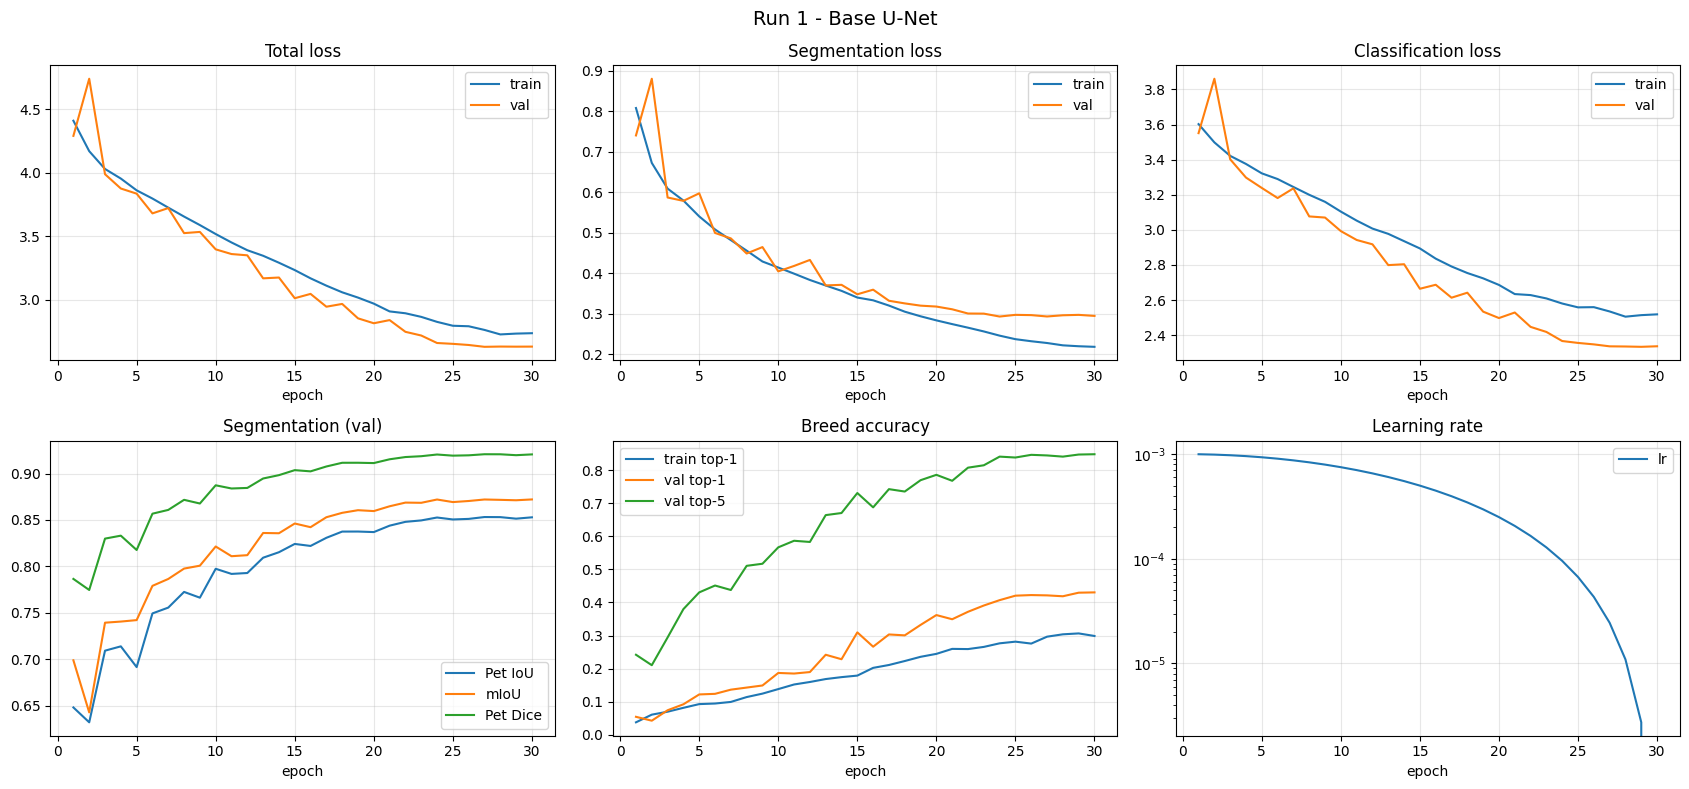

In [ ]:
plot_curves(base_hist, "Run 1 - Base U-Net")

In [ ]:
base_res, base_cms = evaluate(base_model, f"{CKPT_DIR}/base_unet_bestloss.pth")
base_res

,Pixel Acc,Pet IoU,mIoU,Pet Dice,mDice,Cls Acc,Top-5 Acc,Species Acc,Precision,Recall,F1
Train,0.9527,0.8935,0.9076,0.9438,0.9515,0.5739,0.9515,0.9519,0.5891,0.5734,0.5370
Val,0.9332,0.8531,0.8720,0.9208,0.9315,0.4215,0.8448,0.9052,0.3980,0.4208,0.3884
Test,0.9348,0.8551,0.8745,0.9219,0.9329,0.4040,0.8323,0.8927,0.3816,0.4037,0.3677


In [ ]:
observe("Run 1 - Base U-Net", base_res, base_hist)

--- Run 1 - Base U-Net ---
Segmentation : Pet IoU 0.8551, mIoU 0.8745, Pet Dice 0.9219
               mIoU reads +0.0194 above Pet IoU because it averages in the easy background class.
Breed        : top-1 0.4040, top-5 0.8323, macro F1 0.3677
               species (cat vs dog) from the predicted breed: 0.8927
               coarse structure is learned (0.89 species) well before fine texture (0.40 breed).
Fit          : train 0.5739 vs val 0.4215, gap +0.1524 -> overfitting - it fits the training set far better than the validation set
Convergence  : val breed accuracy still rising over the last 5 epochs (+0.24 pts/epoch) - this run was stopped early, not converged.


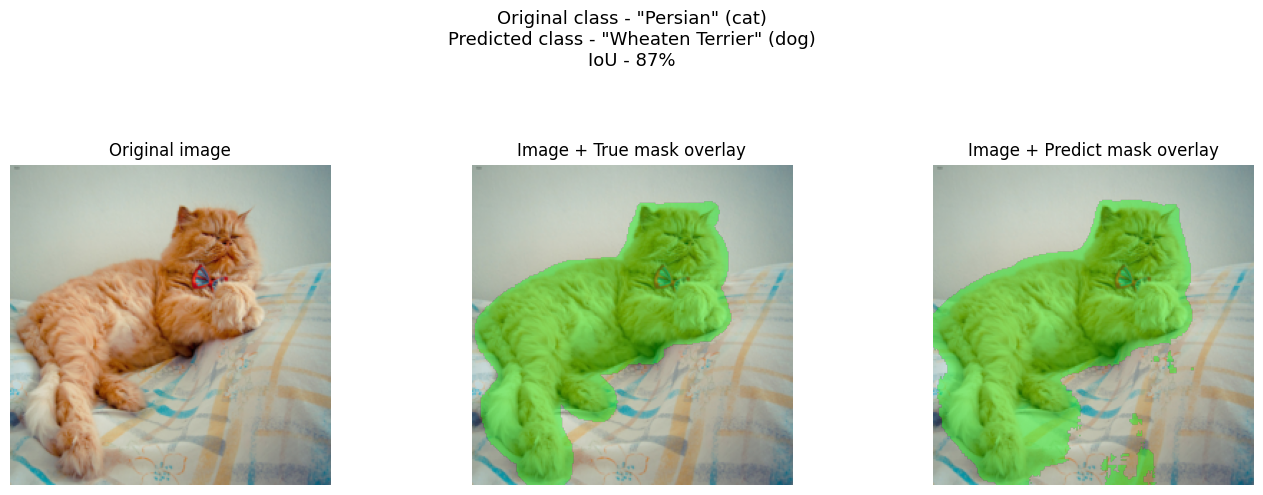

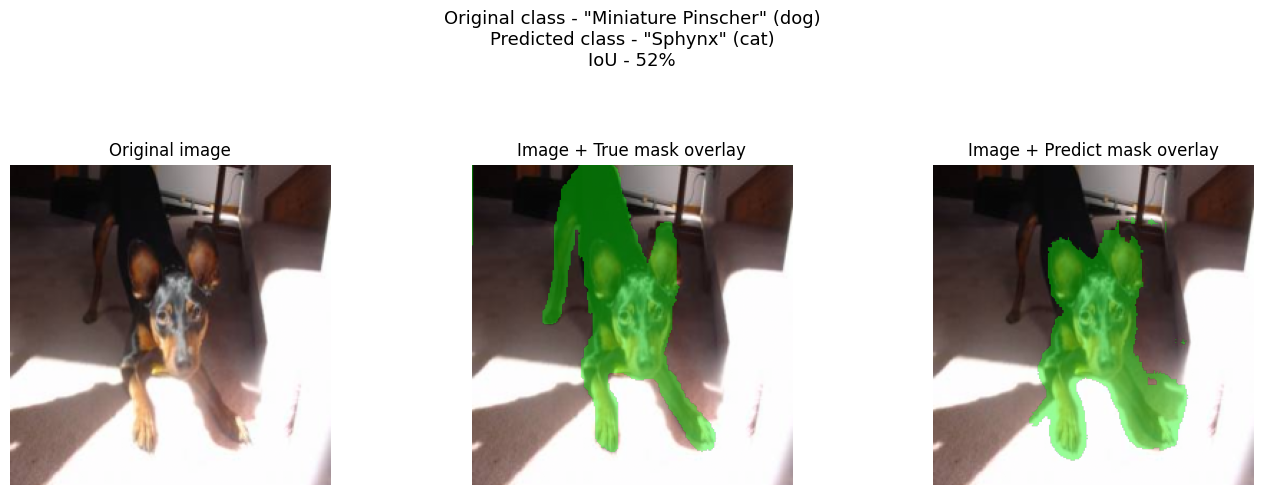

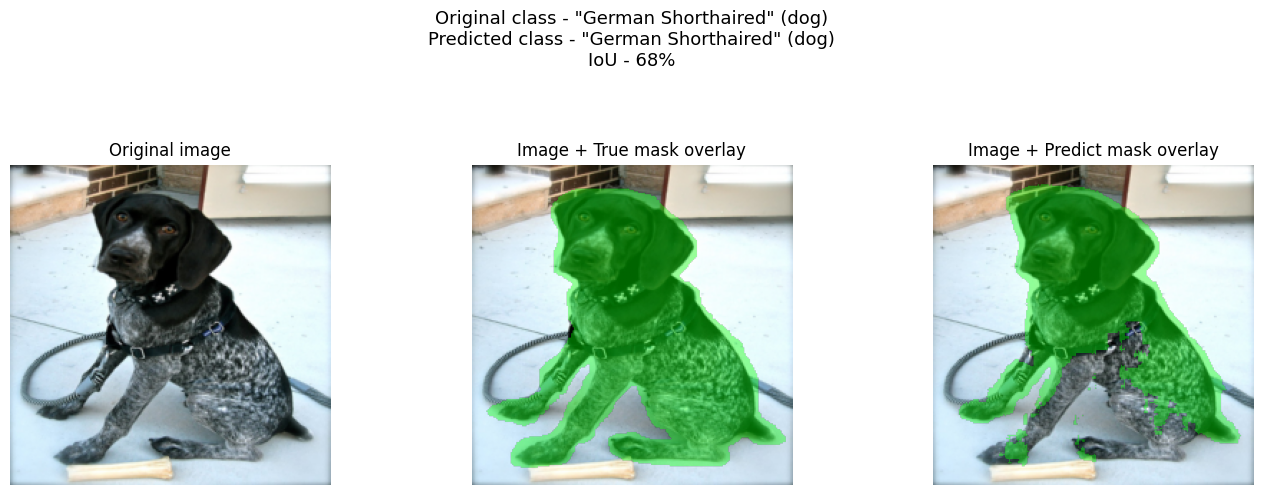

In [ ]:
for i in random.Random(SEED).sample(range(len(test_idx)), 3):
    show_prediction(base_model, Subset(plain_ds, list(test_idx)), i)

Predictions are drawn from the **test** subset. Showing qualitative results on images the model
trained on would flatter it, and an index into the full dataset has a 70% chance of being one.

# 6. Run 2 - Attention U-Net

## The attention gate

A plain U-Net hands the whole encoder feature map across every skip connection, background included.
The attention gate learns to weight it first. It takes the decoder signal as the gating input and the
encoder skip as the other, projects both to a shared channel count, adds them, and squeezes the
result to one channel through a sigmoid. That gives one coefficient between 0 and 1 per pixel, which
multiplies the skip before it is concatenated.

The gate returns the weighted skip **and** the coefficient map, so the maps can be visualised later
without a second forward pass or a hook.

One property worth knowing before reading the results. `psi` ends in `BatchNorm2d(1)` followed by a
sigmoid, which is the standard formulation. BatchNorm on a single channel normalises across the whole
batch and both spatial dimensions, so at initialisation the pre-sigmoid values are centred on zero
with unit variance and roughly half the skip pixels are multiplied by well under 0.5. Every skip
therefore starts out half-suppressed and batch-dependent, and the encoder receives a noisier gradient
than it does in the plain U-Net. The gate is not broken - this is what the paper specifies - but it
does mean this model needs more epochs to reach the same place, which is exactly what the training
log below should show.

In [ ]:
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        # g is the decoder signal, x the encoder skip; alpha is one weight per pixel
        alpha = self.psi(self.relu(self.W_g(g) + self.W_x(x)))
        return x * alpha, alpha

## The model

The encoder, bottleneck and classifier head are unchanged from run 1. The only difference is that
each skip now passes through a gate before being concatenated, so any change in the numbers is
attributable to the gates.

Being precise about what the gates can and cannot affect: the classifier reads the bottleneck, which
sits *before* every gate in the forward pass, so the gates never touch the features the classifier
sees. Any change in breed accuracy is necessarily indirect, arriving through a different segmentation
gradient flowing back into the shared encoder. This is the single most likely thing to be asked about
this architecture, and the answer is in the forward method.

In [ ]:
class MultiTaskAttentionUNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, n_classes=NUM_CLASSES, c=BASE_CH):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.down1 = DoubleConv(in_ch, c)
        self.down2 = DoubleConv(c, c * 2)
        self.down3 = DoubleConv(c * 2, c * 4)
        self.down4 = DoubleConv(c * 4, c * 8)
        self.bottleneck = DoubleConv(c * 8, c * 16)

        self.up4 = nn.ConvTranspose2d(c * 16, c * 8, 2, 2)
        self.att4 = AttentionGate(c * 8, c * 8, c * 4); self.conv4 = DoubleConv(c * 16, c * 8)
        self.up3 = nn.ConvTranspose2d(c * 8, c * 4, 2, 2)
        self.att3 = AttentionGate(c * 4, c * 4, c * 2); self.conv3 = DoubleConv(c * 8, c * 4)
        self.up2 = nn.ConvTranspose2d(c * 4, c * 2, 2, 2)
        self.att2 = AttentionGate(c * 2, c * 2, c);     self.conv2 = DoubleConv(c * 4, c * 2)
        self.up1 = nn.ConvTranspose2d(c * 2, c, 2, 2)
        self.att1 = AttentionGate(c, c, c // 2);        self.conv1 = DoubleConv(c * 2, c)

        self.final = nn.Conv2d(c, out_ch, 1)
        self.classifier = classifier_head(c * 16, n_classes)

    def forward(self, x, return_attn=False):
        d1 = self.down1(x)
        d2 = self.down2(self.pool(d1))
        d3 = self.down3(self.pool(d2))
        d4 = self.down4(self.pool(d3))
        b  = self.bottleneck(self.pool(d4))

        cls = self.classifier(b)                 # reads the bottleneck, before every gate

        g4 = self.up4(b);  a4, w4 = self.att4(g4, d4); u4 = self.conv4(torch.cat([a4, g4], 1))
        g3 = self.up3(u4); a3, w3 = self.att3(g3, d3); u3 = self.conv3(torch.cat([a3, g3], 1))
        g2 = self.up2(u3); a2, w2 = self.att2(g2, d2); u2 = self.conv2(torch.cat([a2, g2], 1))
        g1 = self.up1(u2); a1, w1 = self.att1(g1, d1); u1 = self.conv1(torch.cat([a1, g1], 1))
        seg = self.final(u1)

        if return_attn:
            return seg, cls, [w1, w2, w3, w4]    # 224, 112, 56, 28
        return seg, cls

In [ ]:
p_attn = shape_check(lambda: MultiTaskAttentionUNet(), "Attention U-Net")
print(f"\nAttention gates add {p_attn - p_base:,} parameters ({(p_attn/p_base - 1)*100:.2f}% more).")

Attention U-Net                    seg (2, 1, 224, 224)  cls (2, 37)  params 31,661,074

Attention gates add 351,532 parameters (1.12% more).


## Training

In [ ]:
torch.manual_seed(SEED)
attn_model = MultiTaskAttentionUNet().to(device)
attn_hist  = train_model(attn_model, "attn_unet", train_loader, val_loader)

attn_unet | 31,661,074 params | lr 0.001 | AdamW wd 0.0001 | cosine | 30 epochs
ep   1/30 | 154.2s | train 4.4467 | val 4.4450 | PetIoU 0.6365 | ClsAcc 0.0460 | Top5 0.1913  <- saved [loss, cls]
ep   2/30 | 138.3s | train 4.2315 | val 4.2704 | PetIoU 0.6598 | ClsAcc 0.0433 | Top5 0.2157  <- saved [loss]
ep   3/30 | 137.4s | train 4.1324 | val 4.1497 | PetIoU 0.7130 | ClsAcc 0.0442 | Top5 0.2148  <- saved [loss]
ep   4/30 | 138.3s | train 4.0655 | val 4.0326 | PetIoU 0.7217 | ClsAcc 0.0478 | Top5 0.2193  <- saved [loss, cls]
ep   5/30 | 137.6s | train 4.0088 | val 4.0225 | PetIoU 0.7530 | ClsAcc 0.0442 | Top5 0.2256  <- saved [loss]
ep   6/30 | 137.1s | train 3.9336 | val 3.9979 | PetIoU 0.7567 | ClsAcc 0.0578 | Top5 0.2166  <- saved [loss, cls]
ep   7/30 | 137.1s | train 3.8884 | val 3.8760 | PetIoU 0.7819 | ClsAcc 0.0505 | Top5 0.2356  <- saved [loss]
ep   8/30 | 137.1s | train 3.8350 | val 3.8280 | PetIoU 0.7842 | ClsAcc 0.0569 | Top5 0.2681  <- saved [loss]
ep   9/30 | 137.1s | trai

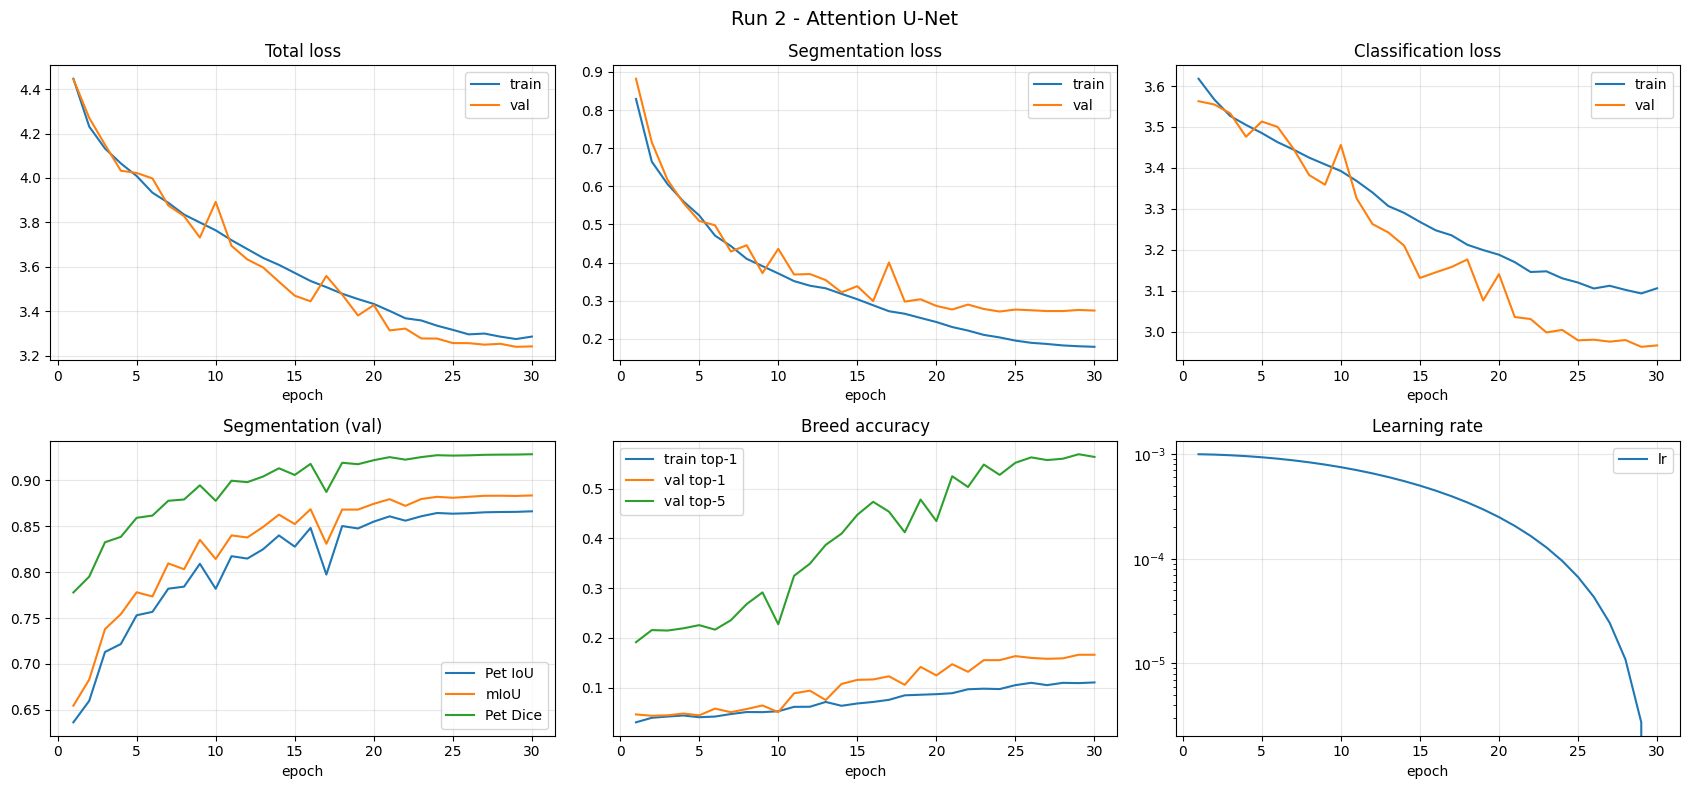

In [ ]:
plot_curves(attn_hist, "Run 2 - Attention U-Net")

In [ ]:
attn_res, attn_cms = evaluate(attn_model, f"{CKPT_DIR}/attn_unet_bestloss.pth")
attn_res

,Pixel Acc,Pet IoU,mIoU,Pet Dice,mDice,Cls Acc,Top-5 Acc,Species Acc,Precision,Recall,F1
Train,0.9618,0.9128,0.9246,0.9544,0.9608,0.1910,0.6750,0.7901,0.1309,0.1907,0.1192
Val,0.9392,0.8655,0.8829,0.9279,0.9377,0.1661,0.5695,0.7491,0.0931,0.1658,0.0984
Test,0.9437,0.8735,0.8907,0.9325,0.9421,0.1632,0.5591,0.7556,0.1092,0.1631,0.0993


In [ ]:
observe("Run 2 - Attention U-Net", attn_res, attn_hist)

--- Run 2 - Attention U-Net ---
Segmentation : Pet IoU 0.8735, mIoU 0.8907, Pet Dice 0.9325
               mIoU reads +0.0172 above Pet IoU because it averages in the easy background class.
Breed        : top-1 0.1632, top-5 0.5591, macro F1 0.0993
               species (cat vs dog) from the predicted breed: 0.7556
               coarse structure is learned (0.76 species) well before fine texture (0.16 breed).
Fit          : train 0.1910 vs val 0.1661, gap +0.0249 -> underfitting - it has not even fitted the training set, so capacity or training length is the binding constraint, not data
Convergence  : val breed accuracy still rising over the last 5 epochs (+0.21 pts/epoch) - this run was stopped early, not converged.


## What the gates actually learned

The single most informative figure for this architecture. Each gate produces one coefficient per
pixel; bright regions are skips the network chose to pass through, dark regions are skips it
suppressed. If the gates are doing their job the pet should be brighter than the background,
most visibly at the finer levels.

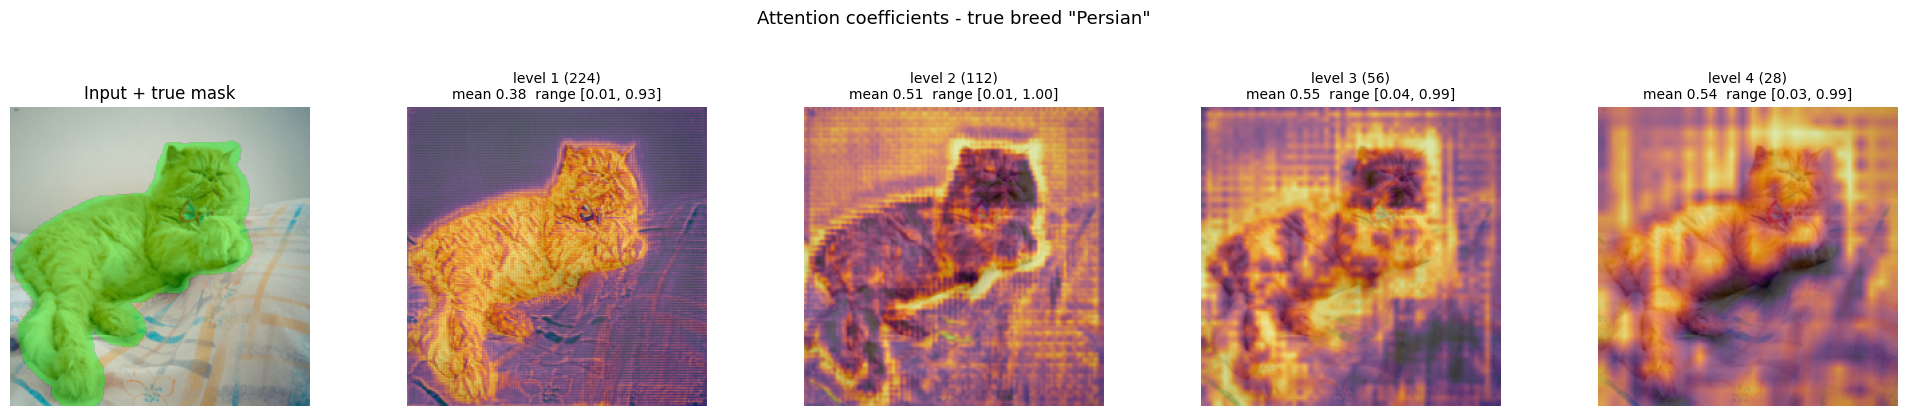

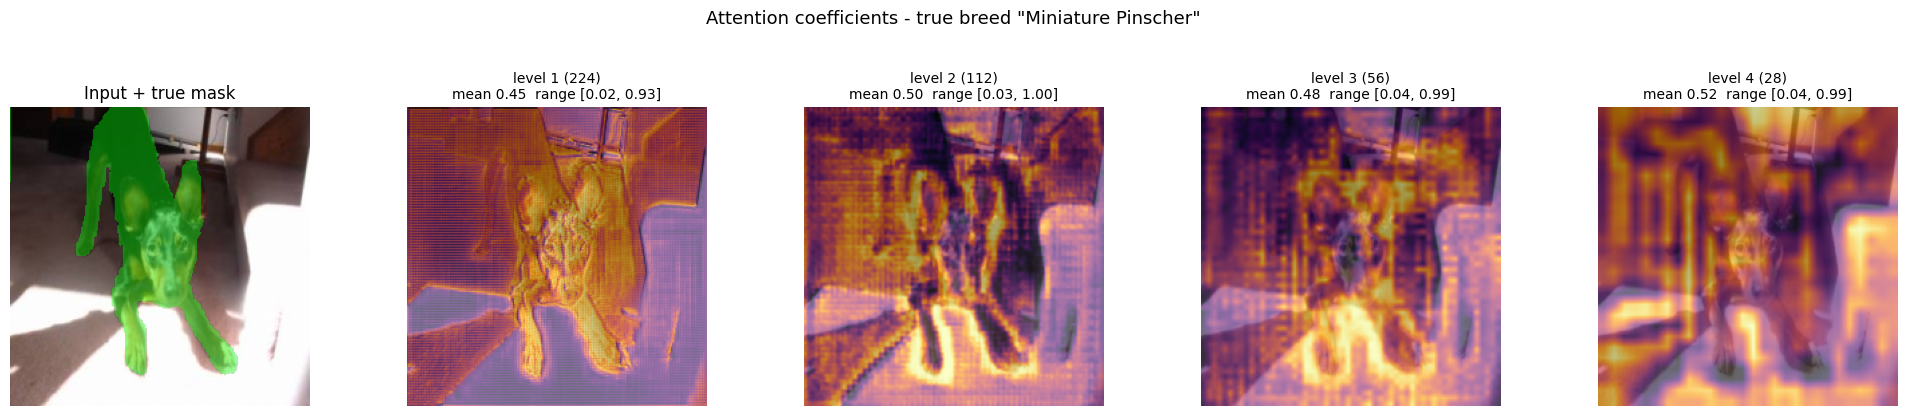

In [ ]:
@torch.no_grad()
def show_attention(model, dataset, idx):
    model.eval()
    image, mask, label = dataset[idx]
    seg, cls, maps = model(image.unsqueeze(0).to(device), return_attn=True)
    img_np = denorm(image)

    fig, axes = plt.subplots(1, 5, figsize=(20, 4.2))
    fig.suptitle(f'Attention coefficients - true breed "{pretty(idx_to_breed[label])}"', fontsize=13)
    axes[0].imshow(img_np); axes[0].imshow(overlay(mask.squeeze().numpy()))
    axes[0].set_title("Input + true mask")
    for ax, m, lvl in zip(axes[1:], maps, ["level 1 (224)", "level 2 (112)", "level 3 (56)", "level 4 (28)"]):
        a = m.float().squeeze().cpu().numpy()
        ax.imshow(img_np)
        ax.imshow(np.array(Image.fromarray((a * 255).astype(np.uint8)).resize((IMG_SIZE, IMG_SIZE),
                  Image.BILINEAR)), cmap="inferno", alpha=0.6)
        ax.set_title(f"{lvl}\nmean {a.mean():.2f}  range [{a.min():.2f}, {a.max():.2f}]", fontsize=10)
    for a in axes: a.axis("off")
    plt.tight_layout(rect=[0, 0, 1, 0.88]); plt.show(); plt.close(fig)

_test_sub = Subset(plain_ds, list(test_idx))
for i in random.Random(SEED).sample(range(len(test_idx)), 2):
    show_attention(attn_model, _test_sub, i)

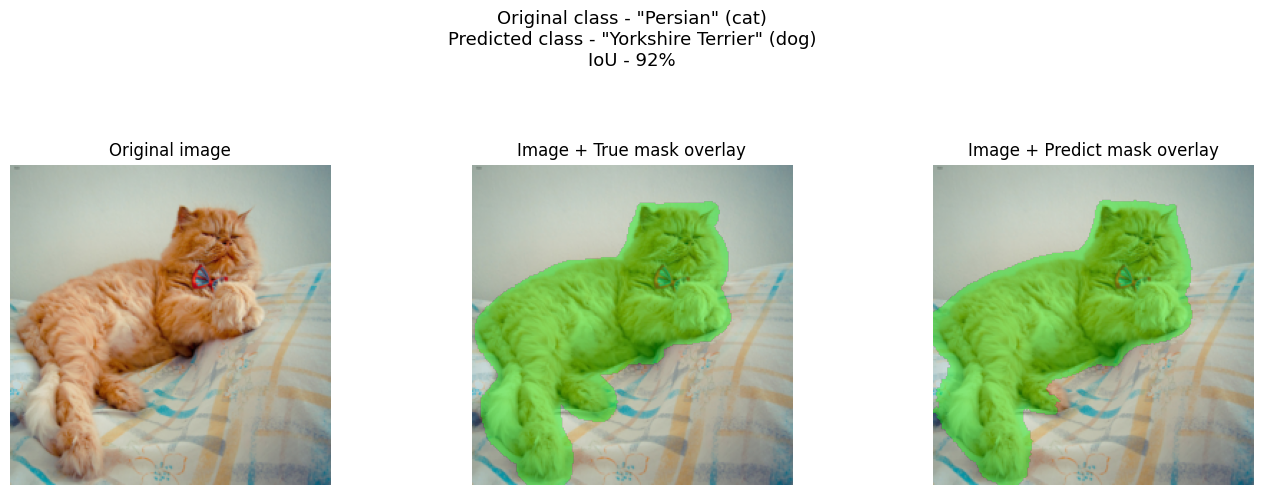

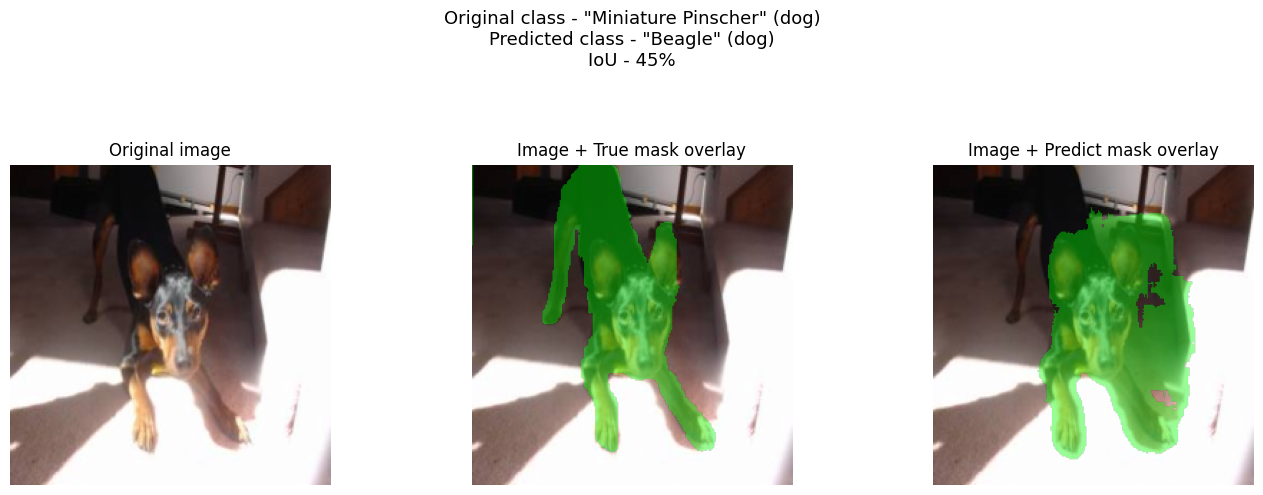

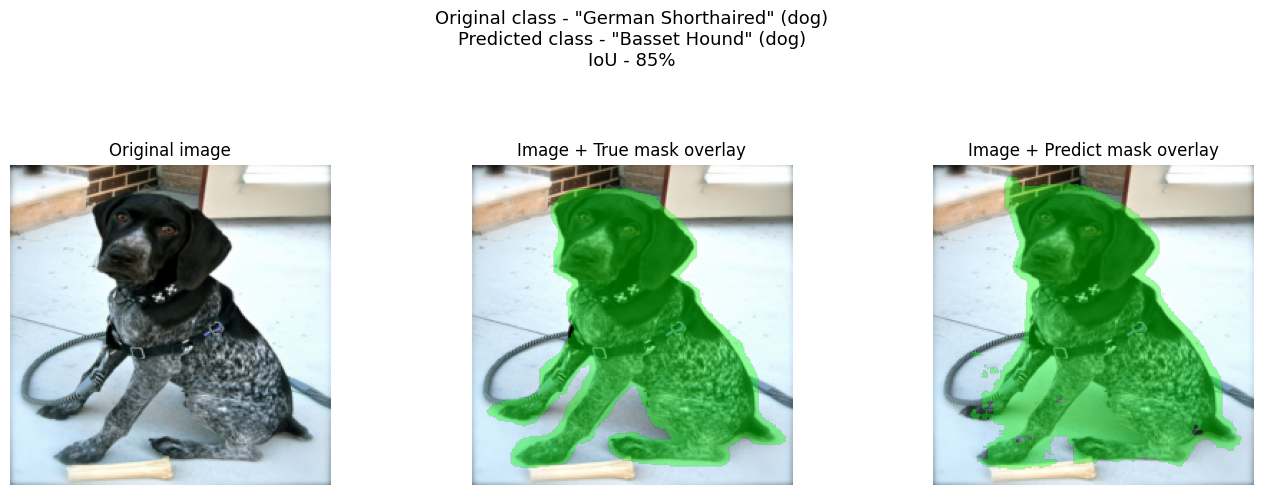

In [ ]:
for i in random.Random(SEED).sample(range(len(test_idx)), 3):
    show_prediction(attn_model, _test_sub, i)

## Run 1 versus run 2

In [ ]:
cmp_12 = compare(base_res, attn_res, "Base U-Net", "Attention U-Net",
                 "attention gates on the four skip connections")

Test set. Only change between these runs: attention gates on the four skip connections

             Base U-Net  Attention U-Net  Change
Pixel Acc        0.9348           0.9437  0.0089
Pet IoU          0.8551           0.8735  0.0184
mIoU             0.8745           0.8907  0.0162
Pet Dice         0.9219           0.9325  0.0106
mDice            0.9329           0.9421  0.0092
Cls Acc          0.4040           0.1632 -0.2408
Top-5 Acc        0.8323           0.5591 -0.2732
Species Acc      0.8927           0.7556 -0.1371
Precision        0.3816           0.1092 -0.2724
Recall           0.4037           0.1631 -0.2406
F1               0.3677           0.0993 -0.2684

Pet IoU: change +0.0184 on 1109 test items is about 1.8 standard errors (suggestive at best).

Cls Acc: change -0.2408 on 1109 test items is about 17.8 standard errors (unlikely to be noise).


In [ ]:
print("Convergence, not just endpoint. Epochs needed to first reach a given validation Pet IoU:\n")
rows = []
for target in [0.60, 0.65, 0.70, 0.75]:
    r = {"target Pet IoU": target}
    for nm, h in [("Base", base_hist), ("Attention", attn_hist)]:
        hit = h.index[h["val_Pet IoU"] >= target]
        r[nm] = int(h.loc[hit[0], "epoch"]) if len(hit) else "not reached"
    rows.append(r)
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nFinal train loss - Base {base_hist['train_loss'].iloc[-1]:.4f} | "
      f"Attention {attn_hist['train_loss'].iloc[-1]:.4f}")
print("If these final training losses differ a lot, the two runs are at different points on their")
print("optimisation curves and the comparison above measures convergence speed, not architecture.")

Convergence, not just endpoint. Epochs needed to first reach a given validation Pet IoU:

 target Pet IoU  Base  Attention
           0.60     1          1
           0.65     3          2
           0.70     3          3
           0.75     7          5

Final train loss - Base 2.7367 | Attention 3.2856
If these final training losses differ a lot, the two runs are at different points on their
optimisation curves and the comparison above measures convergence speed, not architecture.


That last table is the point of the comparison. The claim the Attention U-Net paper makes is about
reaching a given quality sooner, not about a higher ceiling, so the per-epoch history is the evidence
and the final row of the table alone is not.

The final training losses are printed underneath for a specific reason. If one model ends its run at
a substantially higher training loss than the other, the two are not at comparable points on their
optimisation curves, and any difference in the test table is partly a difference in how far each run
got rather than a property of the architecture. That caveat has to be checked, not assumed.

# 7. Run 3 - Attention U-Net with augmentation  *(bonus task 2)*

About 7,390 images across 37 breeds leaves roughly 140 training images per class. That is very little
for fine-grained classification, and augmentation is the standard first response. This section is
**bonus task 2**: state how the data was augmented and measure how much performance changes.

Augmentation applied, to the training set only:

| Transform | Range | Applied to |
|---|---|---|
| Horizontal flip | p = 0.5 | image + mask |
| Rotation | -15 to +15 degrees | image + mask |
| Random resized crop | scale 0.8-1.0, ratio 0.9-1.1 | image + mask |
| Colour jitter | brightness / contrast / saturation 0.2, hue 0.05 | image only |

Same architecture, same seed, same epoch count, same validation loader. The only change is
`aug_train_loader` in place of `train_loader`, and it covers exactly the same images - `tr_idx`
wrapped around the augmenting copy of the dataset rather than the plain one.

Worth predicting the outcome before reading it. Augmentation makes each epoch a harder pass over the
data, so the train-minus-validation gap should shrink. Whether *test* accuracy improves depends on
whether the model was overfitting more than it was underfitting.

In [ ]:
torch.manual_seed(SEED)
aug_model = MultiTaskAttentionUNet().to(device)
aug_hist  = train_model(aug_model, "attn_unet_aug", aug_train_loader, val_loader)

attn_unet_aug | 31,661,074 params | lr 0.001 | AdamW wd 0.0001 | cosine | 30 epochs
ep   1/30 | 138.1s | train 4.5220 | val 4.4957 | PetIoU 0.6057 | ClsAcc 0.0271 | Top5 0.1354  <- saved [loss, cls]
ep   2/30 | 137.2s | train 4.3322 | val 4.2593 | PetIoU 0.6748 | ClsAcc 0.0271 | Top5 0.1354  <- saved [loss]
ep   3/30 | 137.6s | train 4.2502 | val 4.2656 | PetIoU 0.6782 | ClsAcc 0.0325 | Top5 0.1462  <- saved [cls]
ep   4/30 | 137.1s | train 4.1809 | val 4.1212 | PetIoU 0.7244 | ClsAcc 0.0424 | Top5 0.2166  <- saved [loss, cls]
ep   5/30 | 136.6s | train 4.1157 | val 4.0362 | PetIoU 0.7552 | ClsAcc 0.0478 | Top5 0.2166  <- saved [loss, cls]
ep   6/30 | 136.5s | train 4.0631 | val 4.0314 | PetIoU 0.7632 | ClsAcc 0.0451 | Top5 0.2347  <- saved [loss]
ep   7/30 | 136.6s | train 4.0132 | val 3.9573 | PetIoU 0.7840 | ClsAcc 0.0514 | Top5 0.2319  <- saved [loss, cls]
ep   8/30 | 136.7s | train 3.9855 | val 3.9666 | PetIoU 0.7783 | ClsAcc 0.0569 | Top5 0.2437  <- saved [cls]
ep   9/30 | 136.9s

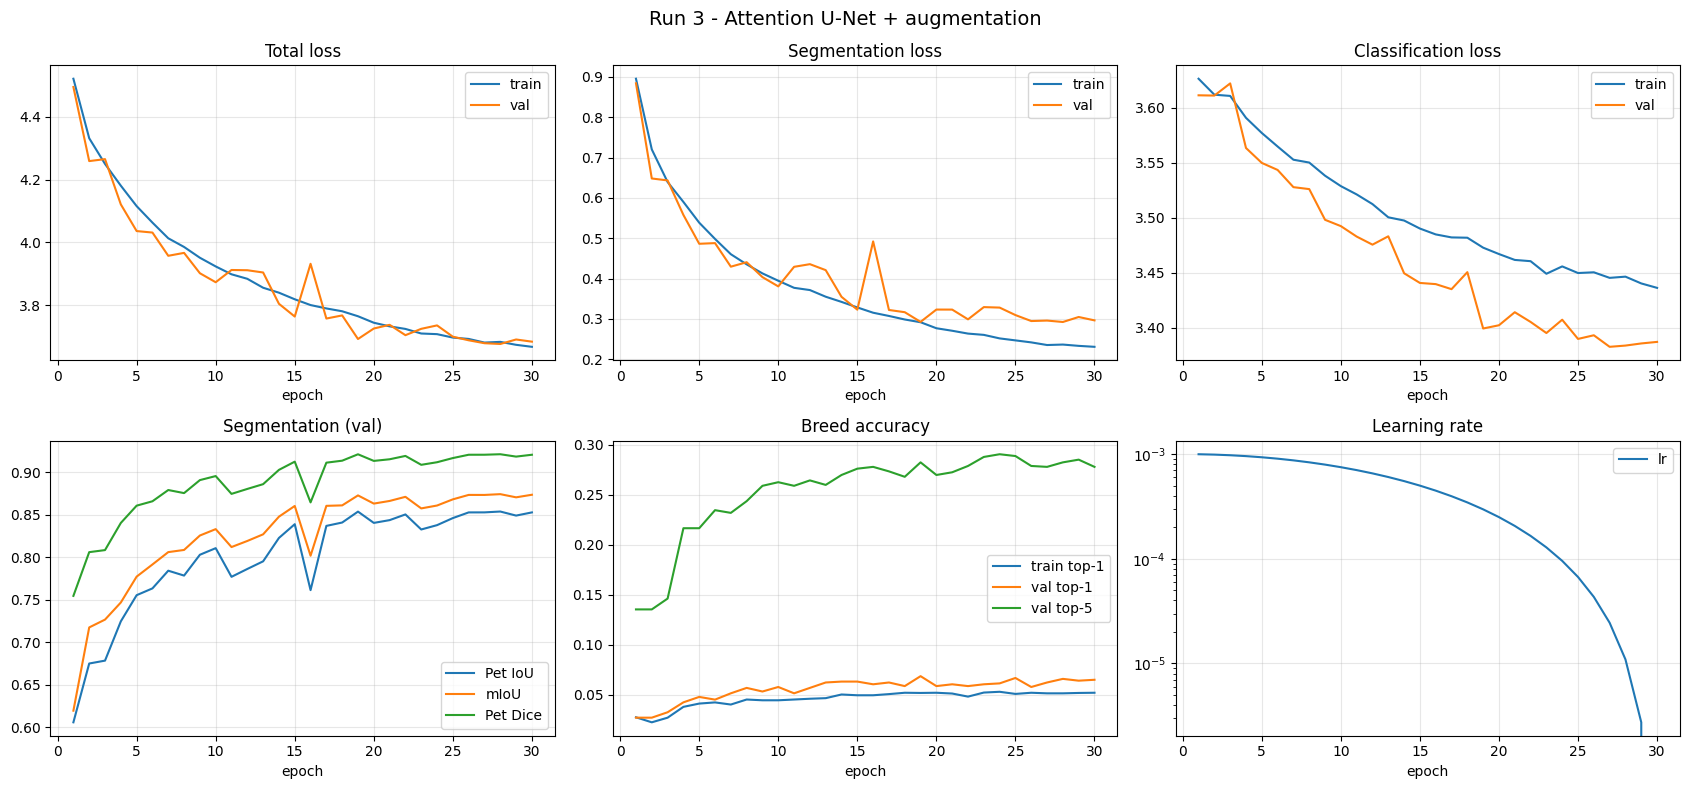

In [ ]:
plot_curves(aug_hist, "Run 3 - Attention U-Net + augmentation")

In [ ]:
aug_res, aug_cms = evaluate(aug_model, f"{CKPT_DIR}/attn_unet_aug_bestloss.pth")
aug_res

,Pixel Acc,Pet IoU,mIoU,Pet Dice,mDice,Cls Acc,Top-5 Acc,Species Acc,Precision,Recall,F1
Train,0.9434,0.8719,0.8899,0.9315,0.9417,0.0682,0.3066,0.7100,0.0163,0.0681,0.0204
Val,0.9347,0.8536,0.8741,0.9210,0.9327,0.0659,0.2825,0.6913,0.0122,0.0658,0.0170
Test,0.9388,0.8613,0.8813,0.9255,0.9368,0.0640,0.3066,0.7142,0.0143,0.0640,0.0189


In [ ]:
observe("Run 3 - Attention U-Net + augmentation", aug_res, aug_hist)

--- Run 3 - Attention U-Net + augmentation ---
Segmentation : Pet IoU 0.8613, mIoU 0.8813, Pet Dice 0.9255
               mIoU reads +0.0200 above Pet IoU because it averages in the easy background class.
Breed        : top-1 0.0640, top-5 0.3066, macro F1 0.0189
               species (cat vs dog) from the predicted breed: 0.7142
Fit          : train 0.0682 vs val 0.0659, gap +0.0023 -> underfitting - it has not even fitted the training set, so capacity or training length is the binding constraint, not data
Convergence  : val breed accuracy flat over the last 5 epochs (+0.16 pts/epoch) - the run has converged.


In [ ]:
cmp_23 = compare(attn_res, aug_res, "No augmentation", "With augmentation",
                 "flip / rotation / resized crop / colour jitter on the training set only")

g0 = attn_res.loc["Train", "Cls Acc"] - attn_res.loc["Val", "Cls Acc"]
g1 = aug_res.loc["Train", "Cls Acc"]  - aug_res.loc["Val", "Cls Acc"]
print(f"\nTrain-minus-validation breed accuracy gap: {g0:+.4f} -> {g1:+.4f}  (change {g1-g0:+.4f})")
print("The gap and the test accuracy can move in different directions. Augmentation reliably closes")
print("the gap, because the model sees a different version of each image every epoch and cannot")
print("memorise them. Test accuracy only improves if overfitting was the binding constraint.")

Test set. Only change between these runs: flip / rotation / resized crop / colour jitter on the training set only

             No augmentation  With augmentation  Change
Pixel Acc             0.9437             0.9388 -0.0049
Pet IoU               0.8735             0.8613 -0.0122
mIoU                  0.8907             0.8813 -0.0094
Pet Dice              0.9325             0.9255 -0.0070
mDice                 0.9421             0.9368 -0.0053
Cls Acc               0.1632             0.0640 -0.0992
Top-5 Acc             0.5591             0.3066 -0.2525
Species Acc           0.7556             0.7142 -0.0414
Precision             0.1092             0.0143 -0.0949
Recall                0.1631             0.0640 -0.0991
F1                    0.0993             0.0189 -0.0804

Pet IoU: change -0.0122 on 1109 test items is about 1.2 standard errors (suggestive at best).

Cls Acc: change -0.0992 on 1109 test items is about 10.4 standard errors (unlikely to be noise).

Train-minus-validat

The geometric transforms move the mask as well as the image, so the segmentation branch is being
augmented too. If the segmentation metrics drop here it is not a bug - the model is being asked to
segment rotated and cropped pets it has never seen in that pose, which is a harder training problem,
and 30 epochs of a harder problem is not equivalent to 30 epochs of an easier one.

# 8. A pretrained encoder

The three runs so far train a 31M-parameter encoder from scratch on about 5,000 images. For
segmentation that is enough - a pet against a background is a coarse cue. For 37 fine-grained breeds
it is not: the differences are in face shape, ear geometry and coat texture, which are expensive to
learn from this little data.

The guidelines say plainly that any classifier architecture may be used and that the goal is to
maximise accuracy, so a pretrained encoder is in scope.

To make transfer learning a measured claim rather than an assertion, the architecture change and the
weight change are separated into two runs:

- **Run 4** - ResNet34 encoder, **random initialisation**, augmented. Differs from run 3 only in the
  encoder architecture.
- **Run 5** - ResNet34 encoder, **ImageNet initialisation**, augmented. Differs from run 4 only in
  the initial weights.

Run 5 minus run 4 is therefore the transfer-learning effect with architecture held fixed.

## A U-Net that accepts any torchvision classifier as its encoder

One class covers every backbone, so runs 4 through 8 share identical decoder, head and training code
and only the encoder differs.

`_stages` slices each torchvision model into five blocks producing feature maps at strides 2, 4, 8,
16 and 32 - the five resolutions a U-Net decoder needs. The slicing differs per architecture because
their internal layouts differ.

**Channel widths are measured, not hardcoded.** The constructor runs a dummy forward pass, records
how many channels each stage emits, and sizes the decoder from that. Two reasons. Writing
`[64, 256, 512, 1024, 1024]` for DenseNet by hand is exactly the sort of thing that is wrong by one
number and produces a shape error 40 minutes into training. And a torchvision version bump that
changed a stage width would silently break hardcoded values, whereas measured ones adapt. The
assertion on `sz` fails loudly and immediately if a backbone does not downsample as expected.

`encoder_parameters` and `decoder_parameters` let the training driver give the two halves different
learning rates, and the driver asserts they partition the model exactly - a parameter left out of the
optimiser would never train and nothing would warn you.

In [ ]:
from torchvision import models as tvm

def _stages(name, pretrained):
    # five modules producing feature maps at strides 2, 4, 8, 16, 32
    w = "IMAGENET1K_V1" if pretrained else None
    if name == "resnet34":
        m = tvm.resnet34(weights=w)
        return [nn.Sequential(m.conv1, m.bn1, m.relu),
                nn.Sequential(m.maxpool, m.layer1), m.layer2, m.layer3, m.layer4]
    if name == "mobilenet_v3_large":
        f = tvm.mobilenet_v3_large(weights=w).features
        return [f[0:2], f[2:4], f[4:7], f[7:13], f[13:]]
    if name == "efficientnet_b0":
        f = tvm.efficientnet_b0(weights=w).features
        return [f[0:2], f[2:3], f[3:4], f[4:6], f[6:]]
    if name == "densenet121":
        f = tvm.densenet121(weights=w).features
        return [f[0:3], f[3:5], f[5:7], f[7:9], f[9:]]
    raise ValueError(f"unknown backbone {name}")


class BackboneUNet(nn.Module):
    def __init__(self, backbone="resnet34", out_ch=1, n_classes=NUM_CLASSES, pretrained=True):
        super().__init__()
        self.backbone_name = backbone
        self.stages = nn.ModuleList(_stages(backbone, pretrained))

        # measure the encoder rather than hardcoding its widths
        with torch.no_grad():
            x = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            ch, sz = [], []
            for s in self.stages:
                x = s(x); ch.append(x.shape[1]); sz.append(x.shape[-1])
        expected = [IMG_SIZE // k for k in (2, 4, 8, 16, 32)]
        assert sz == expected, f"{backbone}: stage sizes {sz}, expected {expected}"
        self.enc_ch = ch

        c0, c1, c2, c3, c4 = ch
        d3, d2, d1, d0 = 256, 128, 64, 48
        self.up4 = nn.ConvTranspose2d(c4, d3, 2, 2); self.dec4 = DoubleConv(d3 + c3, d3)
        self.up3 = nn.ConvTranspose2d(d3, d2, 2, 2); self.dec3 = DoubleConv(d2 + c2, d2)
        self.up2 = nn.ConvTranspose2d(d2, d1, 2, 2); self.dec2 = DoubleConv(d1 + c1, d1)
        self.up1 = nn.ConvTranspose2d(d1, d0, 2, 2); self.dec1 = DoubleConv(d0 + c0, d0)
        self.up0 = nn.ConvTranspose2d(d0, 32, 2, 2); self.dec0 = DoubleConv(32, 32)
        self.final = nn.Conv2d(32, out_ch, 1)
        self.classifier = classifier_head(c4, n_classes)

    def encoder_parameters(self):
        yield from self.stages.parameters()

    def decoder_parameters(self):
        for m in (self.up4, self.dec4, self.up3, self.dec3, self.up2, self.dec2,
                  self.up1, self.dec1, self.up0, self.dec0, self.final, self.classifier):
            yield from m.parameters()

    def forward(self, x):
        e0 = self.stages[0](x)          # stride 2
        e1 = self.stages[1](e0)         # stride 4
        e2 = self.stages[2](e1)         # stride 8
        e3 = self.stages[3](e2)         # stride 16
        e4 = self.stages[4](e3)         # stride 32  <- bottleneck, feeds the classifier

        cls = self.classifier(e4)

        u4 = self.dec4(torch.cat([self.up4(e4), e3], 1))
        u3 = self.dec3(torch.cat([self.up3(u4), e2], 1))
        u2 = self.dec2(torch.cat([self.up2(u3), e1], 1))
        u1 = self.dec1(torch.cat([self.up1(u2), e0], 1))
        u0 = self.dec0(self.up0(u1))    # stride 2 -> full resolution
        return self.final(u0), cls

In [ ]:
_m = BackboneUNet("resnet34", pretrained=False)
print(f"encoder channels per stage - {_m.enc_ch}")
del _m
p_res = shape_check(lambda: BackboneUNet("resnet34", pretrained=False), "ResNet34-U-Net")

encoder channels per stage - [64, 64, 128, 256, 512]
ResNet34-U-Net                     seg (2, 1, 224, 224)  cls (2, 37)  params 24,544,726


## Run 4 - ResNet34 encoder, random initialisation

In [ ]:
torch.manual_seed(SEED)
rnd_model = BackboneUNet("resnet34", pretrained=False).to(device)
rnd_hist  = train_model(rnd_model, "resnet_scratch", aug_train_loader, val_loader)

resnet_scratch | 24,544,726 params | lr 0.001 | AdamW wd 0.0001 | cosine | 30 epochs
ep   1/30 |  85.9s | train 4.4455 | val 4.3834 | PetIoU 0.6131 | ClsAcc 0.0316 | Top5 0.1273  <- saved [loss, cls]
ep   2/30 |  48.1s | train 4.2521 | val 4.2850 | PetIoU 0.6419 | ClsAcc 0.0388 | Top5 0.1661  <- saved [loss, cls]
ep   3/30 |  48.0s | train 4.1276 | val 4.0573 | PetIoU 0.7260 | ClsAcc 0.0614 | Top5 0.2310  <- saved [loss, cls]
ep   4/30 |  48.3s | train 4.0237 | val 3.9369 | PetIoU 0.7443 | ClsAcc 0.0939 | Top5 0.3249  <- saved [loss, cls]
ep   5/30 |  47.2s | train 3.9538 | val 3.8640 | PetIoU 0.7434 | ClsAcc 0.0758 | Top5 0.3637  <- saved [loss]
ep   6/30 |  47.1s | train 3.8744 | val 3.8572 | PetIoU 0.7630 | ClsAcc 0.0884 | Top5 0.3267  <- saved [loss]
ep   7/30 |  47.7s | train 3.8300 | val 3.6873 | PetIoU 0.7884 | ClsAcc 0.1173 | Top5 0.4287  <- saved [loss, cls]
ep   8/30 |  47.2s | train 3.7397 | val 3.6772 | PetIoU 0.7652 | ClsAcc 0.1381 | Top5 0.4341  <- saved [loss, cls]
ep   

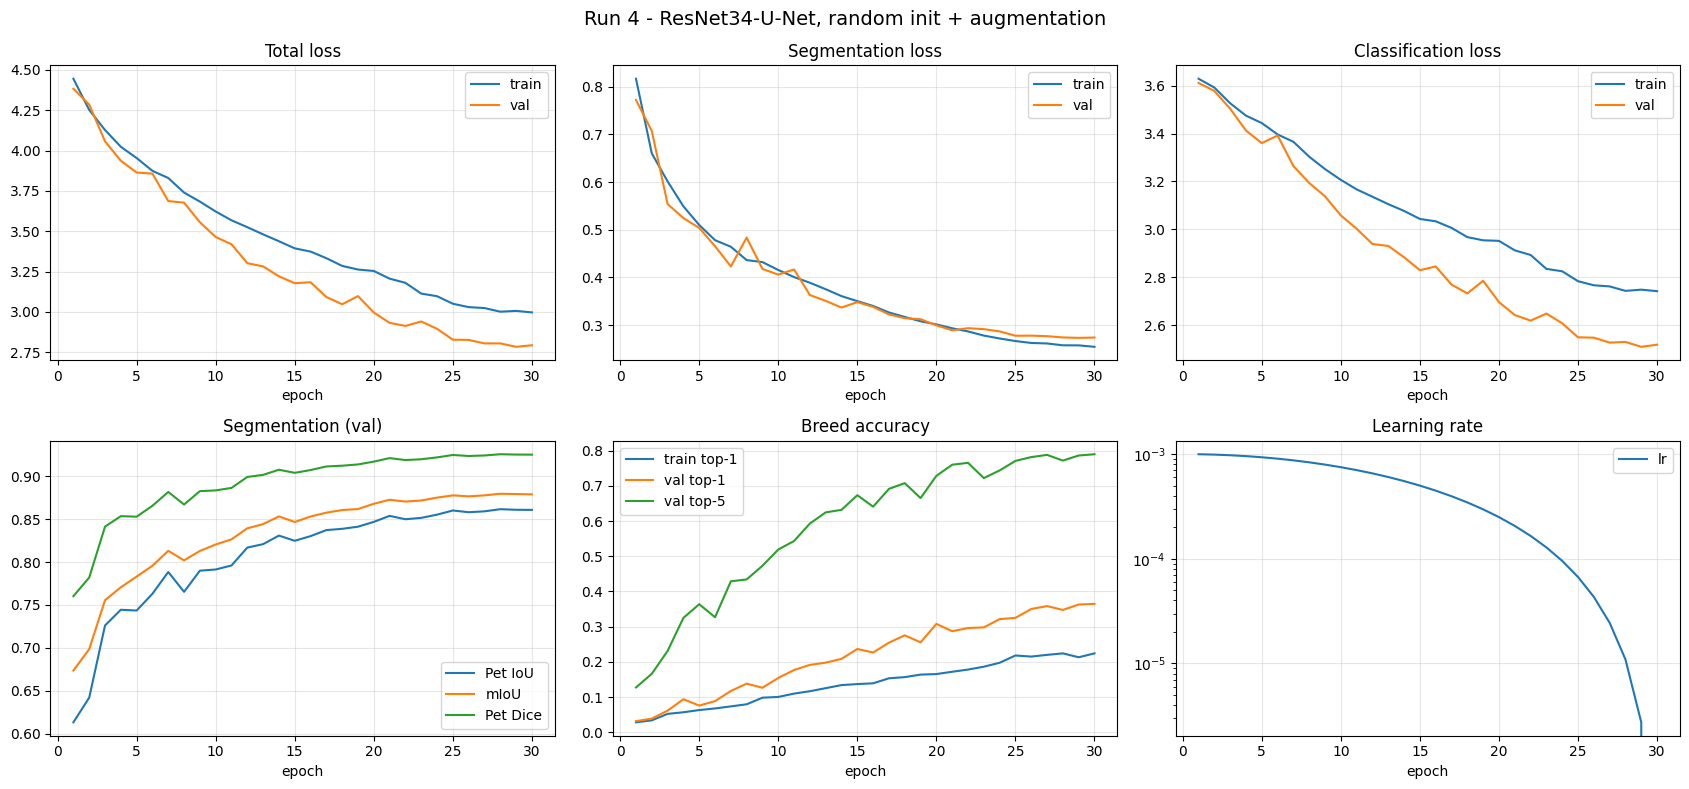

,Pixel Acc,Pet IoU,mIoU,Pet Dice,mDice,Cls Acc,Top-5 Acc,Species Acc,Precision,Recall,F1
Train,0.9466,0.8800,0.8961,0.9362,0.9451,0.4249,0.8767,0.9352,0.4510,0.4244,0.3865
Val,0.9373,0.8609,0.8792,0.9252,0.9356,0.3628,0.7861,0.9116,0.3480,0.3623,0.3291
Test,0.9421,0.8697,0.8876,0.9303,0.9404,0.3715,0.8142,0.9188,0.3541,0.3712,0.3314


In [ ]:
plot_curves(rnd_hist, "Run 4 - ResNet34-U-Net, random init + augmentation")
rnd_res, rnd_cms = evaluate(rnd_model, f"{CKPT_DIR}/resnet_scratch_bestloss.pth")
rnd_res

In [ ]:
observe("Run 4 - ResNet34-U-Net, random init", rnd_res, rnd_hist)

--- Run 4 - ResNet34-U-Net, random init ---
Segmentation : Pet IoU 0.8697, mIoU 0.8876, Pet Dice 0.9303
               mIoU reads +0.0179 above Pet IoU because it averages in the easy background class.
Breed        : top-1 0.3715, top-5 0.8142, macro F1 0.3314
               species (cat vs dog) from the predicted breed: 0.9188
               coarse structure is learned (0.92 species) well before fine texture (0.37 breed).
Fit          : train 0.4249 vs val 0.3628, gap +0.0621 -> underfitting - it has not even fitted the training set, so capacity or training length is the binding constraint, not data
Convergence  : val breed accuracy still rising over the last 5 epochs (+0.33 pts/epoch) - this run was stopped early, not converged.


## Run 5 - ResNet34 encoder, ImageNet initialisation

The encoder is given a learning rate ten times lower than the decoder and the classifier head. The
pretrained filters are already good; training them at the same rate as randomly initialised layers
overwrites them within a few hundred steps and throws away the thing that was worth having.

In [ ]:
torch.manual_seed(SEED)
pre_model = BackboneUNet("resnet34", pretrained=True).to(device)
pre_hist  = train_model(pre_model, "resnet_pretrained", aug_train_loader, val_loader,
                        lr=LR, encoder_lr=ENCODER_LR)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 171MB/s]


resnet_pretrained | 24,544,726 params | encoder lr 0.0001, decoder lr 0.001 | AdamW wd 0.0001 | cosine | 30 epochs
ep   1/30 |  48.2s | train 2.0796 | val 1.4570 | PetIoU 0.8877 | ClsAcc 0.8421 | Top5 0.9829  <- saved [loss, cls]
ep   2/30 |  47.8s | train 1.4630 | val 1.4370 | PetIoU 0.8969 | ClsAcc 0.8403 | Top5 0.9838  <- saved [loss]
ep   3/30 |  47.3s | train 1.2867 | val 1.3556 | PetIoU 0.8991 | ClsAcc 0.8457 | Top5 0.9847  <- saved [loss, cls]
ep   4/30 |  47.5s | train 1.2324 | val 1.3060 | PetIoU 0.9057 | ClsAcc 0.8655 | Top5 0.9865  <- saved [loss, cls]
ep   5/30 |  47.2s | train 1.1576 | val 1.3084 | PetIoU 0.9061 | ClsAcc 0.8818 | Top5 0.9847  <- saved [cls]
ep   6/30 |  46.6s | train 1.1343 | val 1.3141 | PetIoU 0.9045 | ClsAcc 0.8619 | Top5 0.9829
ep   7/30 |  46.7s | train 1.0880 | val 1.2644 | PetIoU 0.9065 | ClsAcc 0.8782 | Top5 0.9901  <- saved [loss]
ep   8/30 |  46.8s | train 1.0422 | val 1.2959 | PetIoU 0.9051 | ClsAcc 0.8727 | Top5 0.9919
ep   9/30 |  46.8s | trai

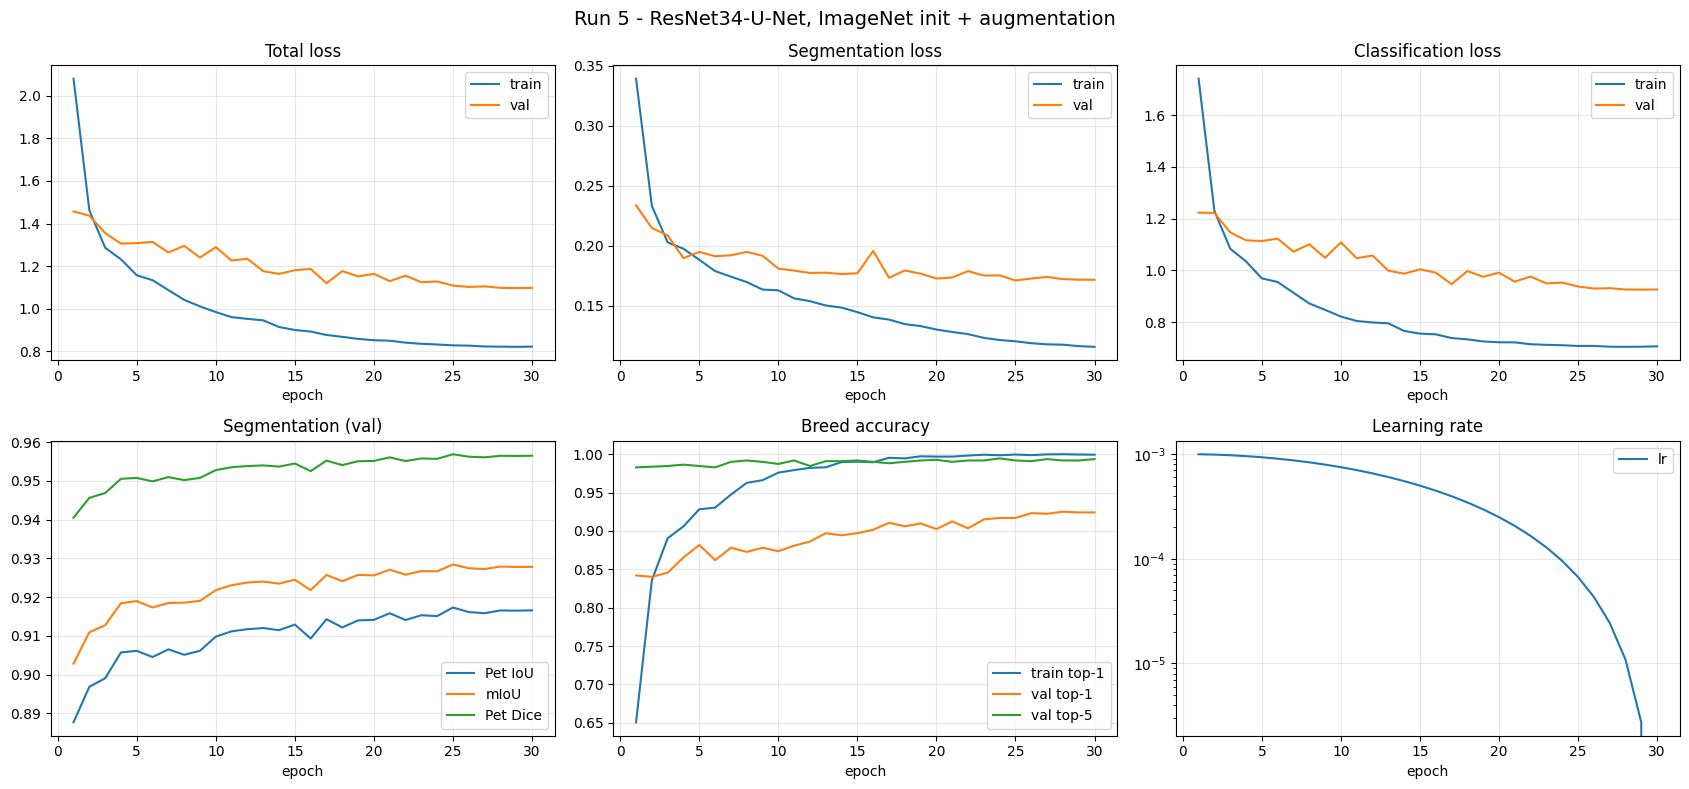

,Pixel Acc,Pet IoU,mIoU,Pet Dice,mDice,Cls Acc,Top-5 Acc,Species Acc,Precision,Recall,F1
Train,0.9734,0.9383,0.9469,0.9682,0.9727,0.9994,1.0000,0.9998,0.9994,0.9994,0.9994
Val,0.9635,0.9165,0.9278,0.9564,0.9625,0.9242,0.9919,0.9973,0.9279,0.9238,0.9239
Test,0.9675,0.9249,0.9353,0.9610,0.9666,0.9098,0.9892,0.9928,0.9169,0.9097,0.9090


In [ ]:
plot_curves(pre_hist, "Run 5 - ResNet34-U-Net, ImageNet init + augmentation")
pre_res, pre_cms = evaluate(pre_model, f"{CKPT_DIR}/resnet_pretrained_bestloss.pth")
pre_res

In [ ]:
observe("Run 5 - ResNet34-U-Net, ImageNet init", pre_res, pre_hist)

--- Run 5 - ResNet34-U-Net, ImageNet init ---
Segmentation : Pet IoU 0.9249, mIoU 0.9353, Pet Dice 0.9610
               mIoU reads +0.0104 above Pet IoU because it averages in the easy background class.
Breed        : top-1 0.9098, top-5 0.9892, macro F1 0.9090
               species (cat vs dog) from the predicted breed: 0.9928
Fit          : train 0.9994 vs val 0.9242, gap +0.0752 -> reasonably balanced
Convergence  : val breed accuracy flat over the last 5 epochs (+0.04 pts/epoch) - the run has converged.


In [ ]:
cmp_34 = compare(aug_res, rnd_res, "Attention U-Net (aug)", "ResNet34-UNet random (aug)",
                 "encoder architecture only - both random init, both augmented")
print("\n" + "=" * 78 + "\n")
cmp_45 = compare(rnd_res, pre_res, "ResNet34 random init", "ResNet34 ImageNet init",
                 "encoder initialisation only - identical architecture, identical training")

Test set. Only change between these runs: encoder architecture only - both random init, both augmented

             Attention U-Net (aug)  ResNet34-UNet random (aug)  Change
Pixel Acc                   0.9388                      0.9421  0.0033
Pet IoU                     0.8613                      0.8697  0.0084
mIoU                        0.8813                      0.8876  0.0063
Pet Dice                    0.9255                      0.9303  0.0048
mDice                       0.9368                      0.9404  0.0036
Cls Acc                     0.0640                      0.3715  0.3075
Top-5 Acc                   0.3066                      0.8142  0.5076
Species Acc                 0.7142                      0.9188  0.2046
Precision                   0.0143                      0.3541  0.3398
Recall                      0.0640                      0.3712  0.3072
F1                          0.0189                      0.3314  0.3125

Pet IoU: change +0.0084 on 1109 test items 

# 9. Runs 6-8 - comparing classifier architectures  *(bonus task 1)*

Bonus task 1 asks for a comparison of at least three well-established classifier architectures.
Four are compared here, each used as the U-Net encoder so that the classifier head reads its
bottleneck, exactly as in the two required models:

| Backbone | Year | Design idea |
|---|---|---|
| ResNet34 | 2015 | residual connections around plain 3x3 stacks |
| DenseNet121 | 2017 | every layer receives all earlier feature maps in its block |
| MobileNetV3-Large | 2019 | depthwise separable convolutions and squeeze-excite, built for low compute |
| EfficientNet-B0 | 2019 | compound width/depth/resolution scaling over MBConv blocks |

Everything except the encoder is held constant: same decoder, same classifier head, same augmented
loader, same optimiser, same schedule, same epochs, same seed, all ImageNet-initialised with the same
discriminative learning rates. ResNet34 is run 5 above and is not retrained.

The loop deletes each model and empties the CUDA cache before the next one, because four backbones
plus the three earlier models will not fit in 16 GB at once.

In [ ]:
bb_results, bb_hists = {}, {}

for bb in BACKBONES:
    print("=" * 78)
    torch.manual_seed(SEED)
    m = BackboneUNet(bb, pretrained=True).to(device)
    print(f"{bb} | encoder channels {m.enc_ch}")
    h = train_model(m, f"bb_{bb}", aug_train_loader, val_loader, lr=LR, encoder_lr=ENCODER_LR)
    r, _ = evaluate(m, f"{CKPT_DIR}/bb_{bb}_bestloss.pth")
    bb_results[bb], bb_hists[bb] = r, h
    print()
    print(r.to_string())
    print()
    observe(bb, r, h)
    del m
    if device == "cuda":
        torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 174MB/s]


mobilenet_v3_large | encoder channels [16, 24, 40, 112, 960]
bb_mobilenet_v3_large | 6,328,518 params | encoder lr 0.0001, decoder lr 0.001 | AdamW wd 0.0001 | cosine | 30 epochs
ep   1/30 | 151.2s | train 2.3554 | val 1.4963 | PetIoU 0.8940 | ClsAcc 0.8060 | Top5 0.9865  <- saved [loss, cls]
ep   2/30 |  46.9s | train 1.4975 | val 1.4116 | PetIoU 0.8901 | ClsAcc 0.8484 | Top5 0.9928  <- saved [loss, cls]
ep   3/30 |  47.0s | train 1.3450 | val 1.3433 | PetIoU 0.8995 | ClsAcc 0.8601 | Top5 0.9919  <- saved [loss, cls]
ep   4/30 |  47.1s | train 1.2507 | val 1.2967 | PetIoU 0.9067 | ClsAcc 0.8745 | Top5 0.9901  <- saved [loss, cls]
ep   5/30 |  47.4s | train 1.1909 | val 1.2790 | PetIoU 0.9081 | ClsAcc 0.8709 | Top5 0.9919  <- saved [loss]
ep   6/30 |  46.5s | train 1.1336 | val 1.2483 | PetIoU 0.9063 | ClsAcc 0.8926 | Top5 0.9910  <- saved [loss, cls]
ep   7/30 |  46.7s | train 1.0938 | val 1.2429 | PetIoU 0.9097 | ClsAcc 0.8890 | Top5 0.9955  <- saved [loss]
ep   8/30 |  46.9s | train

100%|██████████| 20.5M/20.5M [00:00<00:00, 184MB/s]


efficientnet_b0 | encoder channels [16, 24, 40, 112, 1280]
bb_efficientnet_b0 | 7,773,714 params | encoder lr 0.0001, decoder lr 0.001 | AdamW wd 0.0001 | cosine | 30 epochs
ep   1/30 | 130.4s | train 2.0729 | val 1.3245 | PetIoU 0.8962 | ClsAcc 0.8601 | Top5 0.9919  <- saved [loss, cls]
ep   2/30 |  47.2s | train 1.3477 | val 1.2494 | PetIoU 0.8985 | ClsAcc 0.8881 | Top5 0.9919  <- saved [loss, cls]
ep   3/30 |  47.0s | train 1.2261 | val 1.2081 | PetIoU 0.9057 | ClsAcc 0.9088 | Top5 0.9964  <- saved [loss, cls]
ep   4/30 |  47.4s | train 1.1305 | val 1.1434 | PetIoU 0.9100 | ClsAcc 0.9215 | Top5 0.9973  <- saved [loss, cls]
ep   5/30 |  47.3s | train 1.0915 | val 1.2098 | PetIoU 0.9013 | ClsAcc 0.9161 | Top5 0.9946
ep   6/30 |  47.2s | train 1.0484 | val 1.1350 | PetIoU 0.9140 | ClsAcc 0.9197 | Top5 0.9937  <- saved [loss]
ep   7/30 |  46.9s | train 1.0194 | val 1.1087 | PetIoU 0.9156 | ClsAcc 0.9269 | Top5 0.9973  <- saved [loss, cls]
ep   8/30 |  46.9s | train 0.9883 | val 1.1015 |

100%|██████████| 30.8M/30.8M [00:00<00:00, 110MB/s] 


densenet121 | encoder channels [64, 256, 512, 1024, 1024]
bb_densenet121 | 13,191,702 params | encoder lr 0.0001, decoder lr 0.001 | AdamW wd 0.0001 | cosine | 30 epochs
ep   1/30 |  92.1s | train 1.8161 | val 1.2675 | PetIoU 0.8998 | ClsAcc 0.9016 | Top5 0.9973  <- saved [loss, cls]
ep   2/30 |  57.7s | train 1.2732 | val 1.2014 | PetIoU 0.9041 | ClsAcc 0.9079 | Top5 0.9937  <- saved [loss, cls]
ep   3/30 |  56.8s | train 1.1691 | val 1.2338 | PetIoU 0.9083 | ClsAcc 0.8971 | Top5 0.9919
ep   4/30 |  57.1s | train 1.1184 | val 1.1965 | PetIoU 0.9101 | ClsAcc 0.9034 | Top5 0.9892  <- saved [loss]
ep   5/30 |  57.4s | train 1.0714 | val 1.1789 | PetIoU 0.9122 | ClsAcc 0.9143 | Top5 0.9946  <- saved [loss, cls]
ep   6/30 |  57.5s | train 1.0473 | val 1.2003 | PetIoU 0.9135 | ClsAcc 0.9016 | Top5 0.9937
ep   7/30 |  57.2s | train 0.9990 | val 1.1613 | PetIoU 0.9105 | ClsAcc 0.9125 | Top5 0.9919  <- saved [loss]
ep   8/30 |  57.1s | train 0.9922 | val 1.1418 | PetIoU 0.9147 | ClsAcc 0.9106 

In [ ]:
arch       = {"resnet34": pre_res, **bb_results}
arch_hists = {"resnet34": pre_hist, **bb_hists}

arch_tbl = pd.DataFrame({k: v.loc["Test"] for k, v in arch.items()}).T
arch_tbl["train-val gap"] = [round(v.loc["Train", "Cls Acc"] - v.loc["Val", "Cls Acc"], 4)
                             for v in arch.values()]
arch_tbl["params (M)"] = [round(sum(p.numel() for p in
                          BackboneUNet(k, pretrained=False).parameters()) / 1e6, 2) for k in arch]
arch_tbl["min/epoch"] = [round(arch_hists[k]["sec"].mean() / 60, 2) for k in arch]

print("BONUS TASK 1 - classifier architecture comparison (test set)\n")
print(arch_tbl.to_string())
arch_tbl.to_csv(f"{CKPT_DIR}/architecture_comparison.csv")

print(f"\nHighest test breed accuracy   - {arch_tbl['Cls Acc'].idxmax()} "
      f"({arch_tbl['Cls Acc'].max():.4f})")
print(f"Highest test Pet IoU          - {arch_tbl['Pet IoU'].idxmax()} "
      f"({arch_tbl['Pet IoU'].max():.4f})")
print(f"Best accuracy per million par - {(arch_tbl['Cls Acc'] / arch_tbl['params (M)']).idxmax()}")

BONUS TASK 1 - classifier architecture comparison (test set)

                    Pixel Acc  Pet IoU    mIoU  Pet Dice   mDice  Cls Acc  Top-5 Acc  Species Acc  Precision  Recall      F1  train-val gap  params (M)  min/epoch
resnet34               0.9675   0.9249  0.9353    0.9610  0.9666   0.9098     0.9892       0.9928     0.9169  0.9097  0.9090         0.0752       24.54       0.79
mobilenet_v3_large     0.9661   0.9222  0.9328    0.9595  0.9652   0.9062     0.9874       0.9928     0.9095  0.9061  0.9039         0.0884        6.33       0.83
efficientnet_b0        0.9670   0.9239  0.9344    0.9604  0.9661   0.9243     0.9901       0.9964     0.9279  0.9240  0.9227         0.0566        7.77       0.83
densenet121            0.9683   0.9268  0.9369    0.9620  0.9674   0.9306     0.9946       0.9964     0.9346  0.9304  0.9300         0.0650       13.19       0.97

Highest test breed accuracy   - densenet121 (0.9306)
Highest test Pet IoU          - densenet121 (0.9268)
Best accuracy pe

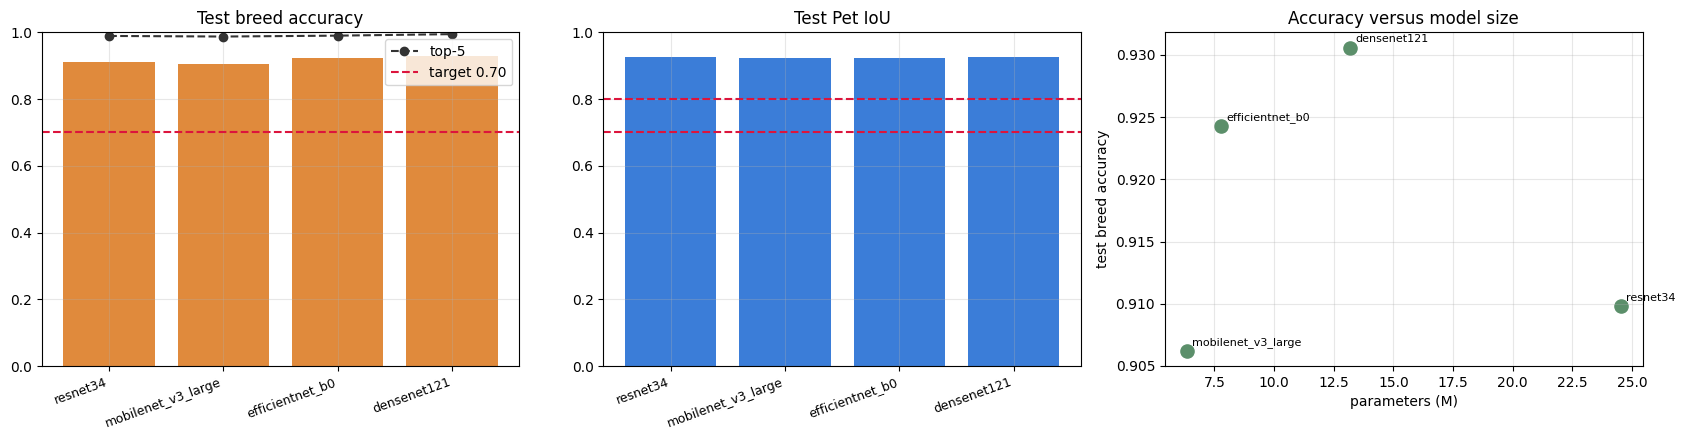

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
names = list(arch_tbl.index)
x = np.arange(len(names))

ax[0].bar(x, arch_tbl["Cls Acc"], color="#e08a3c")
ax[0].plot(x, arch_tbl["Top-5 Acc"], "o--", color="#333", label="top-5")
ax[0].axhline(0.70, ls="--", c="crimson", label="target 0.70")
ax[0].set_title("Test breed accuracy"); ax[0].set_ylim(0, 1); ax[0].legend()

ax[1].bar(x, arch_tbl["Pet IoU"], color="#3b7dd8")
ax[1].axhline(0.70, ls="--", c="crimson"); ax[1].axhline(0.80, ls="--", c="crimson")
ax[1].set_title("Test Pet IoU"); ax[1].set_ylim(0, 1)

ax[2].scatter(arch_tbl["params (M)"], arch_tbl["Cls Acc"], s=90, color="#5b8f6a")
for n, r in arch_tbl.iterrows():
    ax[2].annotate(n, (r["params (M)"], r["Cls Acc"]), fontsize=8,
                   xytext=(4, 4), textcoords="offset points")
ax[2].set_xlabel("parameters (M)"); ax[2].set_ylabel("test breed accuracy")
ax[2].set_title("Accuracy versus model size")

for a in ax[:2]:
    a.set_xticks(x); a.set_xticklabels(names, rotation=20, ha="right", fontsize=9)
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout(); plt.show(); plt.close(fig)

The third panel is the one worth discussing. Raw accuracy is not the only axis - MobileNetV3 is built
for low compute, so landing close to a much larger backbone is a result about efficiency rather than
a failure. Accuracy per parameter and minutes per epoch are both in the table above.

# 10. Full ablation

In [ ]:
ALL = [("1. Base U-Net",              base_res, base_hist),
       ("2. Attention U-Net",         attn_res, attn_hist),
       ("3. Attention U-Net + aug",   aug_res,  aug_hist),
       ("4. ResNet34 random + aug",   rnd_res,  rnd_hist),
       ("5. ResNet34 ImageNet + aug", pre_res,  pre_hist)]
ALL += [(f"{6+i}. {bb} ImageNet + aug", bb_results[bb], bb_hists[bb])
        for i, bb in enumerate(BACKBONES)]

ablation = pd.DataFrame({n: r.loc["Test"] for n, r, _ in ALL}).T
ablation["train-val gap"] = [round(r.loc["Train", "Cls Acc"] - r.loc["Val", "Cls Acc"], 4)
                             for _, r, _ in ALL]
ablation["min/epoch"] = [round(h["sec"].mean() / 60, 2) for _, _, h in ALL]
print("TEST SET - all runs\n")
print(ablation.to_string())
ablation.to_csv(f"{CKPT_DIR}/ablation.csv")

TEST SET - all runs

                                      Pixel Acc  Pet IoU    mIoU  Pet Dice   mDice  Cls Acc  Top-5 Acc  Species Acc  Precision  Recall      F1  train-val gap  min/epoch
1. Base U-Net                            0.9348   0.8551  0.8745    0.9219  0.9329   0.4040     0.8323       0.8927     0.3816  0.4037  0.3677         0.1524       2.06
2. Attention U-Net                       0.9437   0.8735  0.8907    0.9325  0.9421   0.1632     0.5591       0.7556     0.1092  0.1631  0.0993         0.0249       2.29
3. Attention U-Net + aug                 0.9388   0.8613  0.8813    0.9255  0.9368   0.0640     0.3066       0.7142     0.0143  0.0640  0.0189         0.0023       2.28
4. ResNet34 random + aug                 0.9421   0.8697  0.8876    0.9303  0.9404   0.3715     0.8142       0.9188     0.3541  0.3712  0.3314         0.0621       0.81
5. ResNet34 ImageNet + aug               0.9675   0.9249  0.9353    0.9610  0.9666   0.9098     0.9892       0.9928     0.9169  0.9097

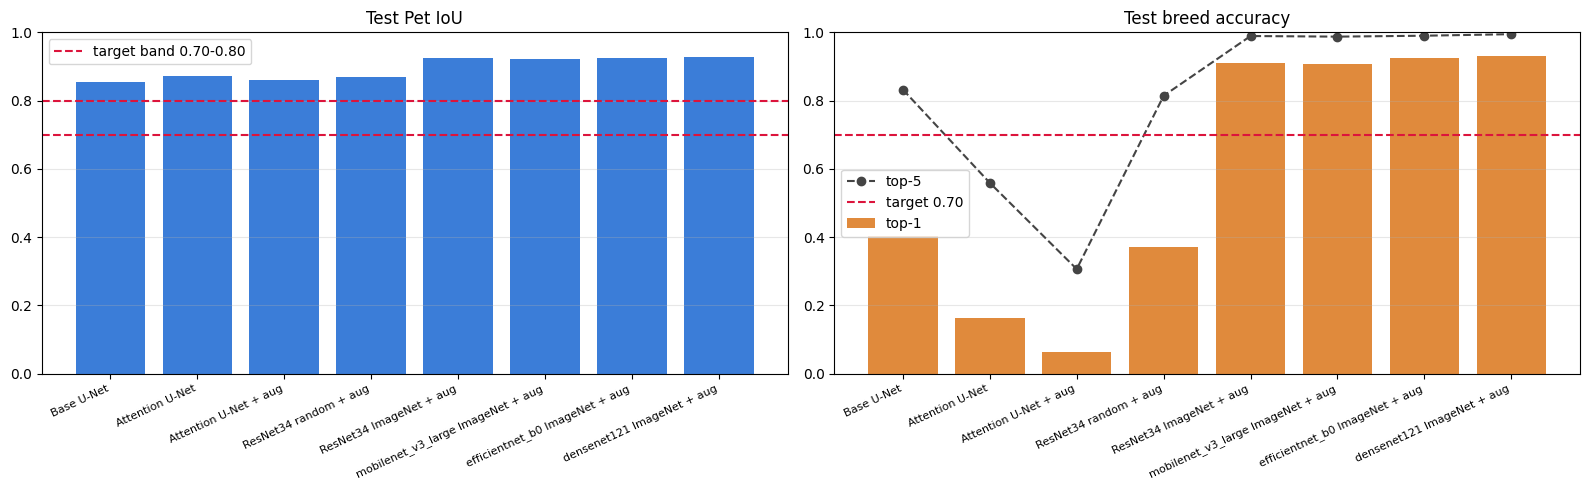

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
short = [n.split(". ", 1)[1] for n, _, _ in ALL]
x = np.arange(len(ALL))

ax[0].bar(x, ablation["Pet IoU"], color="#3b7dd8")
ax[0].axhline(0.70, ls="--", c="crimson", label="target band 0.70-0.80")
ax[0].axhline(0.80, ls="--", c="crimson")
ax[0].set_title("Test Pet IoU"); ax[0].set_ylim(0, 1); ax[0].legend()

ax[1].bar(x, ablation["Cls Acc"], color="#e08a3c", label="top-1")
ax[1].plot(x, ablation["Top-5 Acc"], "o--", color="#444", label="top-5")
ax[1].axhline(0.70, ls="--", c="crimson", label="target 0.70")
ax[1].set_title("Test breed accuracy"); ax[1].set_ylim(0, 1); ax[1].legend()

for a in ax:
    a.set_xticks(x); a.set_xticklabels(short, rotation=25, ha="right", fontsize=8)
    a.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show(); plt.close(fig)

`MODELS` below maps every run to its checkpoint stem and a constructor that rebuilds the architecture.
It is the single place that knows how to reconstitute any model in this notebook, and the demo
notebook uses the same mapping. `pretrained=False` in the constructors is deliberate: the weights come
from the checkpoint, so downloading ImageNet weights first would be wasted work.

In [ ]:
MODELS = {
    "1. Base U-Net":              ("base_unet",         lambda: MultiTaskUNet()),
    "2. Attention U-Net":         ("attn_unet",         lambda: MultiTaskAttentionUNet()),
    "3. Attention U-Net + aug":   ("attn_unet_aug",     lambda: MultiTaskAttentionUNet()),
    "4. ResNet34 random + aug":   ("resnet_scratch",    lambda: BackboneUNet("resnet34", pretrained=False)),
    "5. ResNet34 ImageNet + aug": ("resnet_pretrained", lambda: BackboneUNet("resnet34", pretrained=False)),
}
for i, bb in enumerate(BACKBONES):
    MODELS[f"{6+i}. {bb} ImageNet + aug"] = (f"bb_{bb}",
                                             lambda b=bb: BackboneUNet(b, pretrained=False))

best_name, best_res, best_hist = max(ALL, key=lambda t: t[1].loc["Val", "Cls Acc"])
BEST_CKPT, BEST_CTOR = MODELS[best_name]
BEST_MODEL = BEST_CTOR().to(device)
BEST_MODEL.load_state_dict(torch.load(f"{CKPT_DIR}/{BEST_CKPT}_bestloss.pth", map_location=device))
_, BEST_CMS = evaluate(BEST_MODEL)

print(f"Best model by VALIDATION breed accuracy: {best_name}")
print("(selected on validation, never on test - the test row below is reported, not optimised)\n")
print(best_res.to_string())

t = best_res.loc["Test"]
print("\nAgainst the targets")
print(f"  Segmentation IoU 0.70-0.80 : Pet IoU {t['Pet IoU']:.4f}  "
      f"{'MET' if t['Pet IoU'] >= 0.70 else 'BELOW'}   (mIoU {t['mIoU']:.4f})")
print(f"  Breed accuracy   ~0.70     : {t['Cls Acc']:.4f}  "
      f"{'MET' if t['Cls Acc'] >= 0.68 else 'BELOW'}   (top-5 {t['Top-5 Acc']:.4f})")

Best model by VALIDATION breed accuracy: 7. efficientnet_b0 ImageNet + aug
(selected on validation, never on test - the test row below is reported, not optimised)

       Pixel Acc  Pet IoU    mIoU  Pet Dice   mDice  Cls Acc  Top-5 Acc  Species Acc  Precision  Recall      F1
Train     0.9738   0.9392  0.9477    0.9687  0.9731   0.9988     1.0000       0.9996     0.9988  0.9988  0.9988
Val       0.9658   0.9219  0.9323    0.9594  0.9650   0.9422     0.9973       0.9982     0.9434  0.9418  0.9415
Test      0.9670   0.9239  0.9344    0.9604  0.9661   0.9243     0.9901       0.9964     0.9279  0.9240  0.9227

Against the targets
  Segmentation IoU 0.70-0.80 : Pet IoU 0.9239  MET   (mIoU 0.9344)
  Breed accuracy   ~0.70     : 0.9243  MET   (top-5 0.9901)


# 11. Threshold calibration

Every segmentation number so far uses a 0.5 cut on the sigmoid, which is a default rather than a
choice. The optimum depends on the class balance, and the pet covers only about a third of the frame.

The sweep runs on the **validation** set and the winner is applied once to the test set. Picking a
threshold on test and reporting the result on test is fitting to the test set, and the number would
not mean anything.

In [ ]:
@torch.no_grad()
def threshold_sweep(model, loader, thresholds):
    model.eval()
    inter = {t: np.zeros(2) for t in thresholds}
    union = {t: np.zeros(2) for t in thresholds}
    for im, mk, _ in loader:
        with amp_ctx(USE_AMP):
            probs = torch.sigmoid(model(im.to(device))[0].float()).squeeze(1)
        true = mk.to(device).long().squeeze(1)
        for t in thresholds:
            pred = (probs > t).long()
            for c in (0, 1):
                p, q = (pred == c), (true == c)
                inter[t][c] += (p & q).sum().item()
                union[t][c] += (p | q).sum().item()
    return pd.DataFrame([{"threshold": t,
                          "Pet IoU": (inter[t] / np.maximum(union[t], 1e-9))[1],
                          "mIoU":    (inter[t] / np.maximum(union[t], 1e-9)).mean()}
                         for t in thresholds]).set_index("threshold").round(4)

THRESHOLDS = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
sweep_val = threshold_sweep(BEST_MODEL, val_loader, THRESHOLDS)
best_thr  = float(sweep_val["Pet IoU"].idxmax())
print("Validation sweep\n"); print(sweep_val.to_string())
print(f"\nBest validation threshold - {best_thr}")

sweep_test = threshold_sweep(BEST_MODEL, test_loader, [0.5, best_thr])
print("\nApplied to test\n"); print(sweep_test.to_string())
print(f"\nPet IoU change from recalibrating 0.5 -> {best_thr}: "
      f"{sweep_test.loc[best_thr,'Pet IoU'] - sweep_test.loc[0.5,'Pet IoU']:+.4f}")

fig = plt.figure(figsize=(7, 4))
plt.plot(sweep_val.index, sweep_val["Pet IoU"], "o-", label="val Pet IoU")
plt.plot(sweep_val.index, sweep_val["mIoU"], "s--", label="val mIoU")
plt.axvline(best_thr, ls=":", c="crimson", label=f"chosen {best_thr}")
plt.xlabel("sigmoid threshold"); plt.ylabel("IoU"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Threshold calibration on the validation set")
plt.tight_layout(); plt.show(); plt.close(fig)

Validation sweep

           Pet IoU    mIoU
threshold                 
0.30        0.9197  0.9298
0.35        0.9208  0.9310
0.40        0.9215  0.9317
0.45        0.9218  0.9321
0.50        0.9219  0.9323
0.55        0.9217  0.9323
0.60        0.9212  0.9320
0.65        0.9203  0.9313
0.70        0.9189  0.9303

Best validation threshold - 0.5

Applied to test

           Pet IoU    mIoU
threshold                 
0.5         0.9239  0.9344
0.5         0.9239  0.9344


TypeError: unsupported format string passed to Series.__format__

# 12. Error analysis

## Confusion matrix

In [ ]:
cm_test = BEST_CMS["Test"]
cm_norm = cm_test / np.maximum(cm_test.sum(1, keepdims=True), 1)

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(cm_norm, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels([pretty(b) for b in breeds], rotation=90, fontsize=7)
ax.set_yticklabels([pretty(b) for b in breeds], fontsize=7)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Row-normalised confusion matrix - {best_name} (test)")
n_cats_cls = int(IS_CAT.sum().item())
ax.axhline(n_cats_cls - 0.5, color="w", lw=1.5); ax.axvline(n_cats_cls - 0.5, color="w", lw=1.5)
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show(); plt.close(fig)

print(f"The white lines separate the {n_cats_cls} cat breeds (top-left) from the "
      f"{NUM_CLASSES - n_cats_cls} dog breeds.")
print("Mass inside a diagonal block is a confusion between similar breeds; mass in an")
print("off-diagonal block is a cat/dog error, which is a much cruder mistake.")

## Per-class accuracy

In [ ]:
per_cls = np.diag(cm_test) / np.maximum(cm_test.sum(1), 1)
tbl = pd.DataFrame({"breed": [pretty(b) for b in breeds],
                    "species": ["cat" if c else "dog" for c in IS_CAT.cpu().numpy()],
                    "support": cm_test.sum(1), "accuracy": per_cls.round(3)}).sort_values("accuracy")

print("Five hardest breeds\n"); print(tbl.head(5).to_string(index=False))
print("\nFive easiest breeds\n"); print(tbl.tail(5).iloc[::-1].to_string(index=False))
print(f"\nCat breeds mean accuracy - {tbl[tbl.species=='cat'].accuracy.mean():.3f}")
print(f"Dog breeds mean accuracy - {tbl[tbl.species=='dog'].accuracy.mean():.3f}")

print("\nMost frequent single confusions (true -> predicted)\n")
off = cm_test.copy(); np.fill_diagonal(off, 0)
for a, b in zip(*np.unravel_index(np.argsort(off, axis=None)[::-1][:8], off.shape)):
    if off[a, b] == 0: break
    same = "same species" if IS_CAT[a] == IS_CAT[b] else "CROSS-SPECIES"
    print(f"  {pretty(breeds[a]):<30} -> {pretty(breeds[b]):<30} {off[a,b]:>3}  ({same})")

fig = plt.figure(figsize=(13, 4))
o = np.argsort(per_cls)
plt.bar(range(NUM_CLASSES), per_cls[o],
        color=["#5b8ff9" if IS_CAT[i] else "#e08a3c" for i in o])
plt.xticks(range(NUM_CLASSES), [pretty(breeds[i]) for i in o], rotation=90, fontsize=7)
plt.ylabel("test accuracy"); plt.title("Per-breed accuracy (blue = cat, orange = dog)")
plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show(); plt.close(fig)

## Failure cases

Random samples show what the model usually does. The failures show where it breaks, which is the more
informative half. Two kinds are pulled out: the lowest-IoU segmentations, and the classifications
that were both wrong and confident.

In [ ]:
@torch.no_grad()
def worst_cases(model, ids, k=3, thr=0.5):
    model.eval()
    sub = Subset(plain_ds, list(ids))
    ld = DataLoader(sub, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    ious, wrong_conf, pos = [], [], 0
    for im, mk, lb in ld:
        im, mk, lb = im.to(device), mk.to(device), lb.to(device)
        with amp_ctx(USE_AMP):
            sl, cl = model(im)
        pred = (torch.sigmoid(sl.float()) > thr).long().squeeze(1)
        true = mk.long().squeeze(1)
        i = ((pred == 1) & (true == 1)).sum((1, 2)).float()
        u = ((pred == 1) | (true == 1)).sum((1, 2)).float()
        biou = (i / u.clamp(min=1)).cpu().numpy()
        conf, arg = torch.softmax(cl.float(), 1).max(1)
        for j in range(im.size(0)):
            ious.append((biou[j], pos + j))
            if arg[j] != lb[j]:
                wrong_conf.append((conf[j].item(), pos + j, lb[j].item(), arg[j].item()))
        pos += im.size(0)

    print(f"--- {k} worst segmentations by Pet IoU ---")
    for v, j in sorted(ious)[:k]:
        show_prediction(model, sub, j, thr=thr)

    print(f"--- {k} most confident misclassifications ---")
    for c, j, t_, p_ in sorted(wrong_conf, reverse=True)[:k]:
        print(f'{c*100:.1f}% confident that "{pretty(idx_to_breed[t_])}" '
              f'was "{pretty(idx_to_breed[p_])}"')
        show_prediction(model, sub, j, thr=thr)

worst_cases(BEST_MODEL, test_idx, k=3, thr=best_thr)

## Which checkpoint to report

Each run saved two checkpoints: the epoch with the lowest total validation loss, and the epoch with
the highest validation breed accuracy. Every table above uses the loss-selected one. This compares
them on the test set.

Both criteria are computed on validation, so choosing between them is legitimate model selection
rather than peeking at test. The point is that a single combined loss is a compromise between two
tasks and does not necessarily land on the best epoch for either.

In [ ]:
rows = []
for nm, (ck, ctor) in MODELS.items():
    m = ctor().to(device)
    for tag, suffix in [("best val loss", "bestloss"), ("best val ClsAcc", "bestcls")]:
        r, _ = evaluate(m, f"{CKPT_DIR}/{ck}_{suffix}.pth", splits=("Test",))
        rows.append({"run": nm, "checkpoint": tag,
                     "Pet IoU": r.loc["Test", "Pet IoU"], "Cls Acc": r.loc["Test", "Cls Acc"],
                     "Top-5 Acc": r.loc["Test", "Top-5 Acc"]})
    del m
    if device == "cuda": torch.cuda.empty_cache()

print(pd.DataFrame(rows).pivot(index="run", columns="checkpoint").round(4).to_string())
print("\nWhere the ClsAcc-selected column is meaningfully higher, selecting on total validation loss")
print("alone was discarding the better classifier that the same run had already produced.")

# 14. Saving the artefacts for the demo notebook

In [ ]:
config = {
    "breeds": breeds, "num_classes": NUM_CLASSES, "img_size": IMG_SIZE,
    "seed": SEED, "batch_size": BATCH_SIZE, "epochs": EPOCHS, "base_ch": BASE_CH,
    "imagenet_mean": IMAGENET_MEAN, "imagenet_std": IMAGENET_STD,
    "backbones": BACKBONES,
    "best_run": best_name, "best_ckpt": BEST_CKPT, "best_threshold": best_thr,
    "best_class": type(BEST_MODEL).__name__,
    "best_backbone": getattr(BEST_MODEL, "backbone_name", None),
    "split_sizes": {"train": len(tr_idx), "val": len(val_idx), "test": len(test_idx)},
    "test_stems": [os.path.basename(samples[int(i)]["image"])[:-4] for i in test_idx],
    "val_stems":  [os.path.basename(samples[int(i)]["image"])[:-4] for i in val_idx],
    "test_metrics": {k: float(v) for k, v in best_res.loc["Test"].items()},
    "all_runs": {n: {k: float(v) for k, v in r.loc["Test"].items()} for n, r, _ in ALL},
    "quick_test": QUICK_TEST,
}

with open(f"{CKPT_DIR}/config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Artefacts in /kaggle/working\n")
total = 0
for f in sorted(os.listdir(CKPT_DIR)):
    if f.endswith((".pth", ".csv", ".json")):
        mb = os.path.getsize(os.path.join(CKPT_DIR, f)) / 1e6
        total += mb
        print(f"  {f:<44} {mb:8.1f} MB")
print(f"\n  {'total':<44} {total:8.1f} MB")
print(f"\nBest run   - {best_name}")
print(f"Checkpoint - {BEST_CKPT}_bestloss.pth")
print(f"Threshold  - {best_thr}")
if QUICK_TEST:
    print("\n>> QUICK_TEST run. These artefacts are not the real results.")